# DATAML final project 2025-26
### beraud@lpccaen.in2p3.fr, lehaut@lpccaen.in2p3.fr, vacheret@lpccaen.in2p3.fr

Please read carefully and to the end the information below :

Please save your working copy of this notebook with the format : `M2dataML_lastname.ipynb`
as for the first exam you will submit it to ecampus.

All your code, the explanation of your work and reference citations should be contained in this notebook.


if you use LLM coders for any aspect of this work please mention where and how. Using large language models as an helper and a way to improve your understanding is not discouraged here. As mentioned during the course, what we strongly discourage is delegating your critical sense and methodology to a LLM. If you decide to do this, this is at your own risk as we look for some very specific output.  

The project is designed such that you can reuse materials available during the course and given at tutorials therefore we are not expecting any "vibe coding".

 You should be able to achieve this with most CPU based PC but the project can also be done on colab or kaggle.. If you decide to use a GPU, please give the option to use a CPU so we can run the notebook easily to test the result when marking.

NOTE :  ML projects can be infinitely complex, **use your time wisely**.

The deadline for submitting the link/notebook of your project is set to the **16th January 2026 at midnight**.
Any submission after the deadline will be penalised by a first 20% drop in marks and more as time passes. it will not be possible to submit after the deadline + 1 day.    


### Dataset and project questions

In this project, you are in charge of identifying top quark events from QCD jets using simulated events from a collider experiment. The pandas dataset file available is `data.h5` with keys ,`train`, `val` and `test`. Label 0 are QCD jets and label 1 are top jet events.

**Question 1** : Explore your dataset variables.
1. Plot the different variables
2. Comment on your findings and implement a pytorch dataset and dataloader
3. Describe potential features and other specifics in each categories if you find some.

**Question 2**: Implement a neural network model and use supevised learning to identify top jets from QCD jets. Explain your strategy to find the best performance i.e. obtaining the best accuracy as possible.
1. Provide details about the chosen loss function, plot of of training/val losses and  accuracy at minima and other metrics you think are useful to have if you wish.
2. Explain when you stop the training of the model and why.
3. Give the final accuracy on the test set, the output probably and class label predicted for each class.

NOTE: it is advised to start simple.

**Question 3** : We need to estimate the epistemic uncertainty of the model in order to compare with previous. Choose a method to estimate this error and explain your choice.

**Question 4** : In our experiment it is crucial to limit the contamination of QCD events  to 5% and retain as many top jets as possible. Test this selection criterion on the test and show that you are not selecting more than 5% background events.

**Question 5** : More data would help with getting better performance. What data augmentation would you choose in order to improve the current performance. Explain in details and optionality you can implement it to demonstrate the improvement.

**Question 6 (optional)** : Once the top jets are selected, the energy of the jet needs to be extimated. Take the same dataset to train another model that predicts the energy of the jet.


# **Question : 01 - Data Analysis and Pytorch Dataset and Dataloaders**


---

**Data Analysis**
In this section I aim to analyse two things:

1.   **Sanity Checks**

Here I will count the labels for two events, missing values, features range, and check for outliers/tails.

2.   **Correlation between inputs and label**

Here we will go through all our input features and our focus will be on pointing out strong and redundant features through different techniques.


*   Distribution plots (hist/KDE per class)
*   Uinvariate ROC-AUC
*   Correlation Matrix(Spearman)
*   UMAP




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
train = pd.read_hdf('/content/data.h5', "train")
val   = pd.read_hdf('/content/data.h5', "val")
test  = pd.read_hdf('/content/data.h5', "test")

In [ ]:
train

,label,jet_pt,jet_eta,jet_phi,jet_energy,jet_mass,jet_nparticles
0,1,577.800537,-0.679422,-2.216681,739.194519,182.267319,34
1,1,591.206543,-0.155397,-0.267447,620.245728,163.312531,31
2,1,553.178528,0.347139,0.197707,609.803467,165.750031,54
3,1,632.224182,0.691948,2.342296,805.673340,159.575562,40
4,1,577.201050,0.159411,2.372692,636.903137,252.876190,70
...,...,...,...,...,...,...,...
7601,0,611.916565,0.665018,1.318276,754.072510,51.862347,20
7602,0,632.310242,0.001642,-1.724743,646.602234,135.192856,43
7603,0,564.668518,1.522717,0.331314,1357.993164,73.737709,29
7604,0,566.710815,1.406818,1.952834,1227.329224,49.675194,23


So, We have following input features:


1.   Jet_pt
2.   Jet_eta
3.   Jet_phi
4.   Jet_energy
5.   Jet_nparticles
6.   Jet_mass



In [ ]:
FEATURES = ["jet_pt","jet_eta","jet_phi","jet_energy","jet_mass","jet_nparticles"]
TARGET = "label"

# Basic shapes
print("Shapes:")
print("  train:", train.shape)
print("  val  :", val.shape)
print("  test :", test.shape)

# Missing values
print("\nMissing values per split (features + label):")
for name, df in [("train", train), ("val", val), ("test", test)]:
    miss = df[FEATURES + [TARGET]].isna().sum()
    total_miss = int(miss.sum())
    print(f"\n{name}: total missing = {total_miss}")
    print(miss)

# Class balance (imbalance)
print("\nClass balance (counts and fractions):")
for name, df in [("train", train), ("val", val), ("test", test)]:
    counts = df[TARGET].value_counts().sort_index()
    fracs = df[TARGET].value_counts(normalize=True).sort_index()
    print(f"\n{name}:")
    print(pd.DataFrame({"count": counts, "fraction": fracs}))

# Quick feature ranges (min/max) to catch weird values
print("\nFeature ranges (min/max) — train:")
ranges = pd.DataFrame({
    "min": train[FEATURES].min(),
    "max": train[FEATURES].max()
})
print(ranges)

# Quick outlier hint via quantiles (train)
print("\nTrain quantiles (1%, 50%, 99%) — helps spot heavy tails/outliers:")
qs = train[FEATURES].quantile([0.01, 0.50, 0.99]).T
qs.columns = ["q01", "q50", "q99"]
print(qs)


Shapes:
  train: (7606, 7)
  val  : (2516, 7)
  test : (4039, 7)

Missing values per split (features + label):

train: total missing = 0
jet_pt            0
jet_eta           0
jet_phi           0
jet_energy        0
jet_mass          0
jet_nparticles    0
label             0
dtype: int64

val: total missing = 0
jet_pt            0
jet_eta           0
jet_phi           0
jet_energy        0
jet_mass          0
jet_nparticles    0
label             0
dtype: int64

test: total missing = 0
jet_pt            0
jet_eta           0
jet_phi           0
jet_energy        0
jet_mass          0
jet_nparticles    0
label             0
dtype: int64

Class balance (counts and fractions):

train:
       count  fraction
label                 
0       6106  0.802787
1       1500  0.197213

val:
       count  fraction
label                 
0       2012  0.799682
1        504  0.200318

test:
       count  fraction
label                 
0       2034   0.50359
1       2005   0.49641

Feature ranges (mi

In [ ]:
idx = pd.IndexSlice
train.groupby(TARGET)[FEATURES].describe().loc[:, idx[:, ['mean', 'std', '50%']]]

jet_pt                          jet_eta                      \
             mean        std         50%      mean       std       50%   
label                                                                    
0      595.380859  28.920010  592.535675 -0.003747  0.986374 -0.004515   
1      595.423584  28.266705  592.398346 -0.002831  0.892187  0.017549   

        jet_phi                      jet_energy                          \
           mean       std       50%        mean         std         50%   
label                                                                     
0      0.037951  1.805819  0.069779  945.443665  391.038910  788.921936   
1      0.007494  1.818004  0.009800  890.632812  333.538544  755.721588   

         jet_mass                        jet_nparticles                   
             mean        std         50%           mean        std   50%  
label                                                                     
0       95.847610  50.500679   82.799831      43.209957  18.828285  41.0  
1      176.789124  25.481939  174.169914      55.180000  14.190625  53.0

# **Sanity Check Observations (Train / Val / Test)**

---

* **Dataset sizes:**  
  Train = **7606** samples, Val = **2516**, Test = **4039** (each with **6 features + 1 label**).

* **Missing values:**  
  There are **no missing values** in any split (train/val/test all have **0** missing entries).  
  So, **no imputation** is needed.

* **Class balance (imbalance):**  
  - **Train:** label 0 = **6106 (80.28%)**, label 1 = **1500 (19.72%)** → **imbalanced** (about **4:1**)  
  - **Val:** label 0 = **2012 (79.97%)**, label 1 = **504 (20.03%)** → similar to train  
  - **Test:** label 0 = **2034 (50.36%)**, label 1 = **2005 (49.64%)** → **almost balanced**
  
  This is important: training/validation are imbalanced, so accuracy alone can be misleading; metrics like **ROC-AUC / F1** can be useful later.

* **Feature ranges (train):**  
  - **jet_pt:** ~**550–650** (narrow range)  
  - **jet_eta:** ~**−2 to +2**  
  - **jet_phi:** ~**−π to +π** (as expected for an angle)  
  - **jet_energy:** ~**554–2396** (wide range, heavy tail likely)  
  - **jet_mass:** ~**9–328**  
  - **jet_nparticles:** **7–132**

* **Quantiles (train) show heavy tails / outliers mainly in energy and mass:**  
  - **jet_energy:** q50 ≈ **781**, q99 ≈ **2125** → strong right tail  
  - **jet_mass:** q50 ≈ **98.6**, q99 ≈ **252** → right tail  
  - **jet_nparticles:** q50 ≈ **44**, q99 ≈ **96** → right tail  
  
  This supports using **standardization** (and potentially log/robust scaling later if needed), but the values do not look physically impossible.

* **Consistency note:**  
  Train and Val have similar class fractions (~80/20), but Test is ~50/50.  
  This is not an error, but it means the test evaluation is on a more balanced set than the training distribution.


In [ ]:
FEATURES = ["jet_pt", "jet_eta", "jet_phi", "jet_energy", "jet_mass", "jet_nparticles"]
TARGET = "label"

In [ ]:
train.head()

,label,jet_pt,jet_eta,jet_phi,jet_energy,jet_mass,jet_nparticles
0,1,577.800537,-0.679422,-2.216681,739.194519,182.267319,34
1,1,591.206543,-0.155397,-0.267447,620.245728,163.312531,31
2,1,553.178528,0.347139,0.197707,609.803467,165.750031,54
3,1,632.224182,0.691948,2.342296,805.673340,159.575562,40
4,1,577.201050,0.159411,2.372692,636.903137,252.876190,70


# **Features Analysis**

---



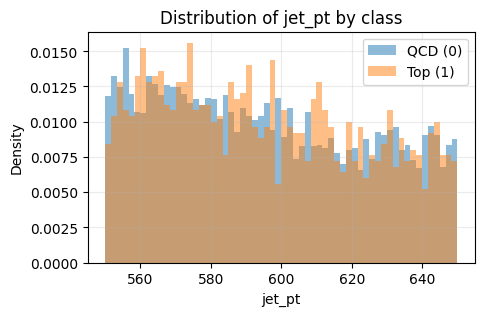

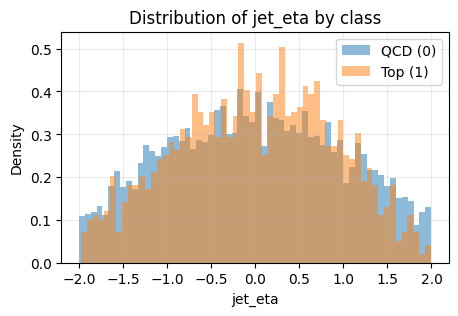

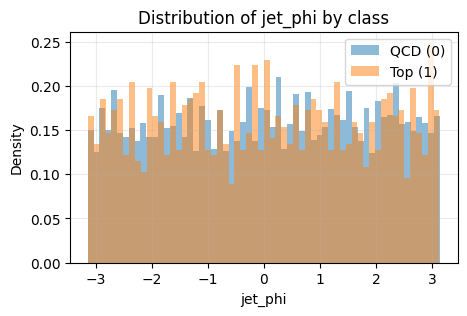

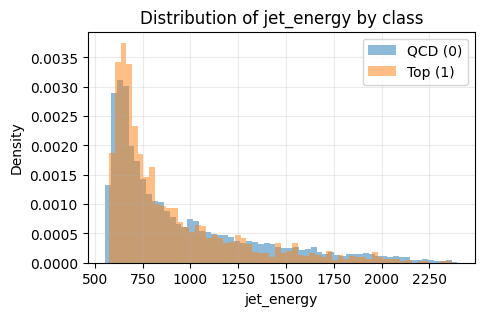

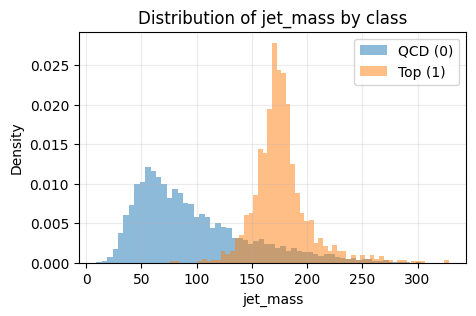

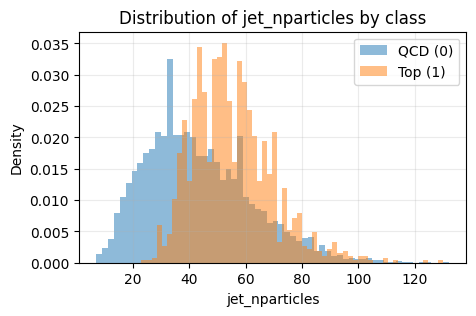

In [ ]:
def plot_feature_distributions(df, features, target="label", bins=60):
    y = df[target].values
    for f in features:
        x0 = df.loc[y==0, f].values
        x1 = df.loc[y==1, f].values

        plt.figure(figsize=(5,3))
        plt.hist(x0, bins=bins, density=True, alpha=0.5, label="QCD (0)")
        plt.hist(x1, bins=bins, density=True, alpha=0.5, label="Top (1)")
        plt.title(f"Distribution of {f} by class")
        plt.xlabel(f)
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True, alpha=0.25)
        plt.show()

plot_feature_distributions(train, FEATURES, target=TARGET)


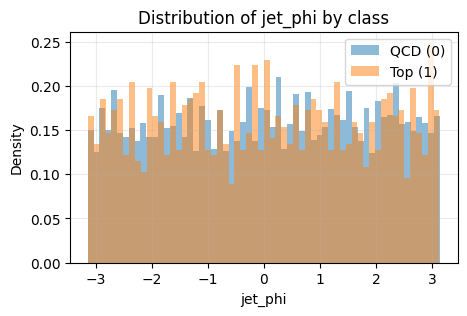

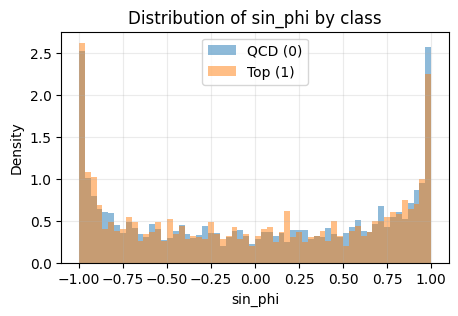

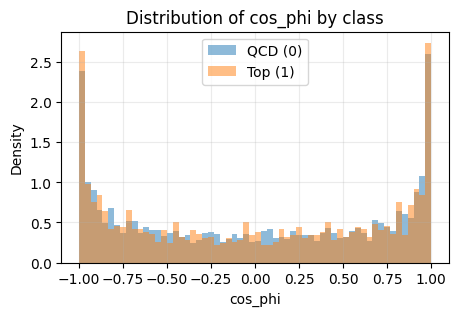

In [ ]:
# Create sin/cos encoding
train2 = train.copy()
train2["sin_phi"] = np.sin(train2["jet_phi"])
train2["cos_phi"] = np.cos(train2["jet_phi"])

TARGET = "label"

def plot_sin_cos_phi_distributions(df, target="label", bins=60):
    y = df[target].values

    for f in ["jet_phi", "sin_phi", "cos_phi"]:
        x0 = df.loc[y==0, f].values
        x1 = df.loc[y==1, f].values

        plt.figure(figsize=(5,3))
        plt.hist(x0, bins=bins, density=True, alpha=0.5, label="QCD (0)")
        plt.hist(x1, bins=bins, density=True, alpha=0.5, label="Top (1)")
        plt.title(f"Distribution of {f} by class")
        plt.xlabel(f)
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True, alpha=0.25)
        plt.show()

plot_sin_cos_phi_distributions(train2, target=TARGET, bins=60)


# **Distribution Plots Analysis**

---

*   The **jet mass (jet_mass)** is the strongest single-feature discriminator. The top-jet distribution is clearly shifted toward higher masses with a peak around **~160–180**, while QCD jets are concentrated at lower masses. A rough visual cut around **jet_mass ≈ 150** appears to separate many top jets from QCD jets, although there remains some overlap.
*   The particle multiplicity (jet_nparticles) is the second most informative feature. Top jets tend to have higher multiplicity (shifted right), and a rough visual cut near **jet_nparticles ≈ 50** could provide some separation, but with noticeably more overlap than jet_mass.



*   The remaining features **(jet_pt, jet_energy, jet_eta, jet_phi)** show substantial overlap between classes across most of their ranges, suggesting they are weak as **standalone predictors**. However, they may still contribute modestly when combined with the stronger variables in a multivariate classifier.




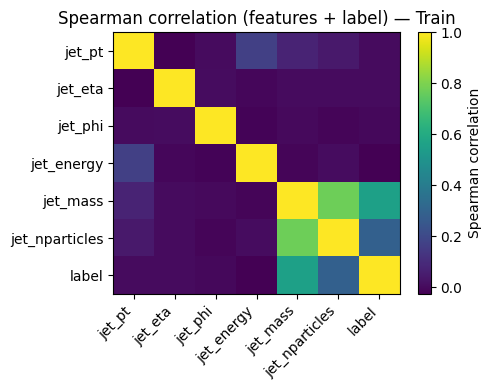

jet_mass          0.555334
jet_nparticles    0.288945
jet_energy       -0.027697
jet_phi          -0.006785
jet_eta           0.002738
jet_pt            0.002266
Name: label, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

corr_all = train[FEATURES + ["label"]].corr(method="spearman")

plt.figure(figsize=(5,4))
plt.imshow(corr_all.values, aspect="auto")
plt.xticks(range(len(corr_all.columns)), corr_all.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_all.index)), corr_all.index)
plt.colorbar(label="Spearman correlation")
plt.title("Spearman correlation (features + label) — Train")
plt.tight_layout()
plt.show()

corr_with_label = corr_all["label"].drop("label").sort_values(key=lambda s: s.abs(), ascending=False)
print(corr_with_label)


# **Spearman Correlation Matrix Analysis**

Since the input variables are continuous and the target label is binary (0/1), we use the Spearman correlation as a rank-based measure of monotonic association between each feature and the label. This does not measure full class separability, but it provides a quick indication of whether larger feature values tend to be associated with class 1 (top jets) or class 0 (QCD).

---


- **jet_mass** shows the strongest positive association with the label **(ρ ≈ 0.555)**. This indicates that higher jet mass values tend to correspond to label 1 more often than label 0, consistent with the clear separation observed in the jet_mass distribution plot.

- **jet_nparticles** has the second highest positive association **(ρ ≈ 0.289)**. This suggests that jets with a larger number of particles are more likely to be top jets, again supporting the conclusions from the distribution plots.

- The remaining features have correlations close to zero, indicating little to no monotonic relationship with the class label:
    **jet_energy ≈ -0.0277,
    jet_phi    ≈ -0.0068,
    jet_eta    ≈  0.0027,
    jet_pt     ≈  0.0023**

Overall, the Spearman results support the EDA conclusion that jet_mass is the strongest single-feature predictor and jet_nparticles is a moderate secondary predictor, while the other variables appear weak as standalone predictors.





In [ ]:
from sklearn.metrics import roc_auc_score

y = train[TARGET].values
auc_scores = []

for f in FEATURES:
    x = train[f].values
    auc = roc_auc_score(y, x)
    auc = max(auc, 1-auc)
    auc_scores.append((f, auc))

auc_scores = sorted(auc_scores, key=lambda t: t[1], reverse=True)
auc_scores


[('jet_mass', np.float64(0.9028985151217382)),
 ('jet_nparticles', np.float64(0.7096029588383012)),
 ('jet_energy', np.float64(0.5200942242602904)),
 ('jet_phi', np.float64(0.5049223714379298)),
 ('jet_eta', np.float64(0.5019862430396331)),
 ('jet_pt', np.float64(0.5016439021727263))]

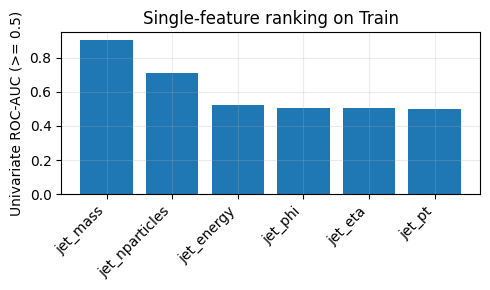

In [ ]:
plt.figure(figsize=(5,3))
plt.bar([a[0] for a in auc_scores], [a[1] for a in auc_scores])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Univariate ROC-AUC (>= 0.5)")
plt.title("Single-feature ranking on Train")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# **Univariate ROC-AUC Analysis**

Here, we quantify how well each feature can distinguish the target class **when used alone**. We compute the **univariate ROC-AUC**, which measures the probability that a randomly chosen **top jet (label 1)** is assigned a higher score than a randomly chosen **QCD jet (label 0)** using that single feature.

---

* **jet_mass** achieves the highest univariate ROC-AUC (**~0.90**), meaning it is a **very strong standalone discriminator**. In practical terms, jet_mass alone ranks top jets above QCD jets most of the time, producing a ROC curve close to the **top-left corner** (high true positive rate at relatively low false positive rate).

* **jet_nparticles** gives the second highest ROC-AUC (**~0.70**), indicating **moderate discriminative power** as a single feature. This supports our earlier conclusion that jet_nparticles is the **second strongest predictor**, although it is clearly weaker than jet_mass.

* The remaining features (**jet_pt, jet_energy, jet_eta, jet_phi**) obtain ROC-AUC values **~0.50**, which is approximately **random guessing** when used alone. This is consistent with the Spearman correlations with the label being close to **0**, indicating no strong monotonic association and weak standalone predictive power.

Overall, the univariate ROC-AUC ranking strongly supports the EDA conclusion that **jet_mass is the primary predictor** and **jet_nparticles is the main secondary predictor**, while the other variables are **weak as standalone predictors**.


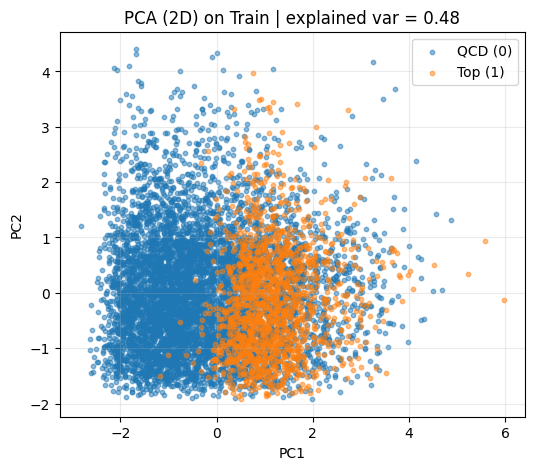

Explained variance ratio: [0.29108557 0.18467116]

PC1 (standardized features) = (+0.1073)*jet_pt_z (-0.0044)*jet_eta_z (-0.0154)*jet_phi_z (-0.0549)*jet_energy_z (+0.7034)*jet_mass_z (+0.7003)*jet_nparticles_z

PC2 (standardized features) = (+0.6643)*jet_pt_z (-0.2785)*jet_eta_z (-0.1286)*jet_phi_z (+0.6806)*jet_energy_z (-0.0266)*jet_mass_z (-0.0263)*jet_nparticles_z


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = train[FEATURES].values
y = train[TARGET].values

# 1) Standardize
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# 2) PCA
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(Xz)

# 3) Plot
plt.figure(figsize=(6,5))
plt.scatter(Z[y==0,0], Z[y==0,1], s=10, alpha=0.5, label="QCD (0)")
plt.scatter(Z[y==1,0], Z[y==1,1], s=10, alpha=0.5, label="Top (1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA (2D) on Train | explained var = {pca.explained_variance_ratio_.sum():.2f}")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

# 4) Print PC equations

weights = pca.components_

def print_pc_equation_standardized(pc_index):
    # PCk = sum_i w_i * feature_i_z
    terms = [f"({w:+.4f})*{name}_z" for w, name in zip(weights[pc_index], FEATURES)]
    eq = " ".join(terms).replace("+ -", "- ")
    print(f"\nPC{pc_index+1} (standardized features) = {eq}")

print_pc_equation_standardized(0)
print_pc_equation_standardized(1)

# **PCA (2D) Analysis**

PCA was applied to the **standardized** input features for visualization (PCA maximizes **variance**, not class separation).

---

* **Explained variance:**  
  The first two components capture **~47.6%** of the total variance  
  (**PC1 = 0.291**, **PC2 = 0.185**).

* **PC1 interpretation (main driver):**  
  **PC1 is dominated by jet_mass and jet_nparticles** with large coefficients  
  (**~0.703** for mass, **~0.700** for nparticles).  
  Thus, **PC1 ≈ “substructure axis”**: higher PC1 → heavier jets + higher multiplicity.

* **What the PCA plot shows:**  
  In the 2D projection, **top jets shift toward higher PC1 values**, consistent with our earlier results  
  (mass and nparticles were strongest in **distributions**, **Spearman**, and **ROC-AUC**).

* **PC2 interpretation:**  
  **PC2 is mainly driven by jet_pt and jet_energy**  
  (**~0.664** for pt, **~0.681** for energy), i.e., a **kinematics axis**.  
  The classes remain **highly overlapped along PC2**, indicating pt/energy explain variance but provide weak separation.

* **Takeaway:**  
  PCA qualitatively confirms that the main class-related direction is aligned with  
  **jet_mass + jet_nparticles**, while overlap remains (classification is not perfectly separable in 2D).


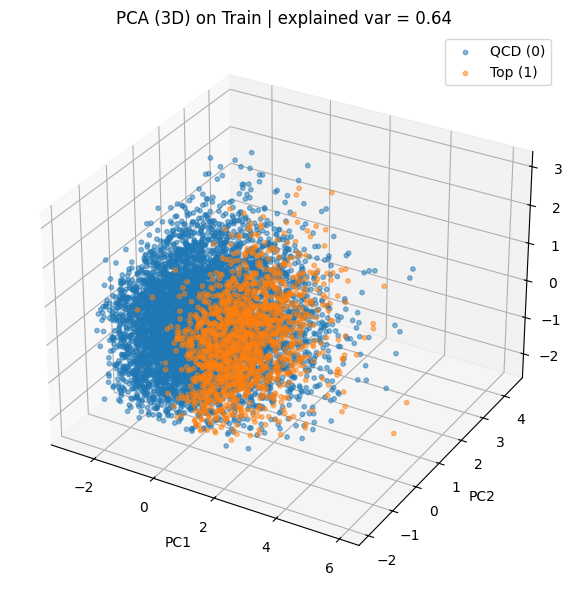

Explained variance ratio: [0.29108557 0.18467116 0.16696497]

PC1 (standardized features) = (+0.1073)*jet_pt_z (-0.0044)*jet_eta_z (-0.0154)*jet_phi_z (-0.0549)*jet_energy_z (+0.7034)*jet_mass_z (+0.7003)*jet_nparticles_z

PC2 (standardized features) = (+0.6643)*jet_pt_z (-0.2785)*jet_eta_z (-0.1286)*jet_phi_z (+0.6806)*jet_energy_z (-0.0266)*jet_mass_z (-0.0263)*jet_nparticles_z

PC3 (standardized features) = (+0.2111)*jet_pt_z (+0.3736)*jet_eta_z (+0.8956)*jet_phi_z (+0.1160)*jet_energy_z (+0.0109)*jet_mass_z (-0.0122)*jet_nparticles_z


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

X = train[FEATURES].values
y = train[TARGET].values

# 1) Standardize
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

# 2) PCA (3 components)
pca = PCA(n_components=3, random_state=0)
Z = pca.fit_transform(Xz)

# 3) 3D Plot
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Z[y==0,0], Z[y==0,1], Z[y==0,2], s=10, alpha=0.5, label="QCD (0)")
ax.scatter(Z[y==1,0], Z[y==1,1], Z[y==1,2], s=10, alpha=0.5, label="Top (1)")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"PCA (3D) on Train | explained var = {pca.explained_variance_ratio_.sum():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


# Print PC equations (PC1, PC2, PC3)

weights = pca.components_  # shape = (3, n_features)

def print_pc_equation_standardized(pc_index):
    terms = [f"({w:+.4f})*{name}_z" for w, name in zip(weights[pc_index], FEATURES)]
    eq = " ".join(terms).replace("+ -", "- ")
    print(f"\nPC{pc_index+1} (standardized features) = {eq}")

print_pc_equation_standardized(0)
print_pc_equation_standardized(1)
print_pc_equation_standardized(2)


# **PCA (3D) Analysis**

PCA was extended to **three components** (PC1–PC3) to visualize more of the dataset variance in a low-dimensional space.

---

* **Explained variance (how much information is shown in 3D):**  
  The first three components capture **~64.3%** of the total variance:  
  **PC1 = 0.291**, **PC2 = 0.185**, **PC3 = 0.167**  → total **0.291+0.185+0.167 ≈ 0.643**.  
  So, 3D PCA shows substantially more structure than 2D PCA.

* **PC1 interpretation (substructure axis):**  
  **PC1 is dominated by jet_mass and jet_nparticles**  
  (**+0.703 mass**, **+0.700 nparticles**).  
  Hence, **PC1 ≈ substructure**: higher PC1 → heavier jets with higher multiplicity.  
  In the 3D scatter, the class shift is mainly along **PC1** (top jets more on the higher-PC1 side), consistent with earlier EDA.

* **PC2 interpretation (kinematics axis):**  
  **PC2 is mainly driven by jet_pt and jet_energy**  
  (**+0.664 pt**, **+0.681 energy**), with smaller negative contributions from angles.  
  This component captures kinematic variation, but the classes still appear **largely overlapped** along PC2, matching the weak standalone predictive power of pt/energy.

* **PC3 interpretation (angular/geometry axis):**  
  **PC3 is dominated by jet_phi** (**+0.896**) and also has some **jet_eta** contribution (**+0.374**).  
  Therefore, **PC3 ≈ angular axis** (mostly φ, then η).  
  In the 3D plot, adding PC3 does **not** create a clean separation between classes; it mostly adds spread/structure related to angular variables, which we already found to be weak predictors (AUC ~0.5, Spearman ~0).

* **Final takeaway (3D vs 2D):**  
  Moving from 2D to 3D increases explained variance from **~47.6% → ~64.3%**, but the main class-related separation still aligns with **PC1 (mass + multiplicity)**.  
  **PC3 mainly captures angular variation** and does not noticeably improve class separability.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


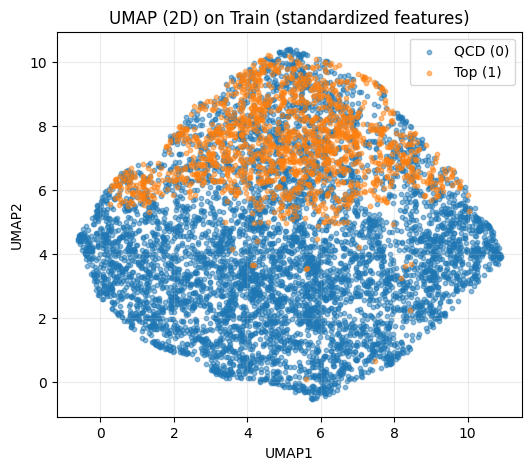

In [ ]:
!pip -q install umap-learn

import umap.umap_ as umap

reducer = umap.UMAP(n_neighbors=30, min_dist=0.2, random_state=0)
Zu = reducer.fit_transform(Xz)

plt.figure(figsize=(6,5))
plt.scatter(Zu[y==0,0], Zu[y==0,1], s=10, alpha=0.5, label="QCD (0)")
plt.scatter(Zu[y==1,0], Zu[y==1,1], s=10, alpha=0.5, label="Top (1)")
plt.title("UMAP (2D) on Train (standardized features)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

# **UMAP (2D) Analysis**

UMAP is a **non-linear** dimensionality reduction method that preserves **local neighborhood structure**. It constructs a nearest-neighbor graph in the original feature space and then finds a 2D embedding (UMAP1, UMAP2) that keeps similar points close together.

---

* **Interpretation of axes:**  
  Unlike PCA, **UMAP1 and UMAP2 are not linear combinations** of the original features and do not have a direct physical meaning. The plot should be interpreted in terms of **relative proximity** (clusters/regions), not in terms of “feature weights”.

* **What we observe:**  
  The top-jet class (label 1) appears more concentrated in a specific region (upper part of the embedding), while QCD jets occupy a broader region. This suggests some **non-linear structure** in the data where top jets form more consistent neighborhoods.


* Also, a partial separation is visible mainly along the **UMAP2** direction: many top-jet points appear concentrated for **UMAP2 ≳ 6**, while QCD points populate a broader region. Along **UMAP1**, there is no clear boundary and the classes remain largely mixed. Importantly, **UMAP1/UMAP2 are not physical input features**; they are learned embedding coordinates, so the plot should be interpreted qualitatively (in terms of clustering/overlap), not as a threshold on a real feature.







# **Feature Categories & Potential Feature Engineering**

We group the six input variables into physically meaningful categories and describe potential derived features that could improve class separability.

---

* **1) Jet Substructure / Internal Composition (strong predictors):**
  - **Features:** **jet_mass**, **jet_nparticles**
  - **Why important:** Top jets typically have a richer multi-prong structure and therefore tend to have **higher jet mass** and **higher particle multiplicity** than QCD jets.
  - **Possible engineered features:**
    - **mass_over_pt = jet_mass / jet_pt**  (scale-invariant style feature)
    - **log_mass = log(jet_mass + ε)**      (stabilizes heavy tails)
    - **log_nparticles = log(jet_nparticles + 1)** (reduces skew)

* **2) Jet Kinematics / Energy Scale (weak alone, potentially supportive):**
  - **Features:** **jet_pt**, **jet_energy**
  - **Observation:** These features show strong overlap between classes as standalone predictors, and they can also carry redundant information (energy and pt are often correlated).
  - **Possible engineered features:**
    - **energy_over_pt = jet_energy / jet_pt** (captures how energy scales with transverse momentum)
    - **log_energy = log(jet_energy + ε)**     (optional if energy is heavy-tailed)

* **3) Angular / Directional Information (weak alone, needs careful handling):**
  - **Features:** **jet_eta**, **jet_phi**
  - **Observation:** These show minimal separation between classes in the current EDA.
  - **Important note:** **jet_phi is periodic** (−π to π), so using raw φ can be misleading for models.
  - **Recommended encoding:**
    - **sin_phi = sin(jet_phi)**
    - **cos_phi = cos(jet_phi)**
    This avoids discontinuity at −π/π and preserves circular geometry.

---

* **Takeaway:**  
  Based on the EDA (distributions, ROC-AUC, and Spearman trend), the most informative category is **substructure (mass + multiplicity)**. The remaining features are weak individually but may still add small improvements when combined in a multivariate model.


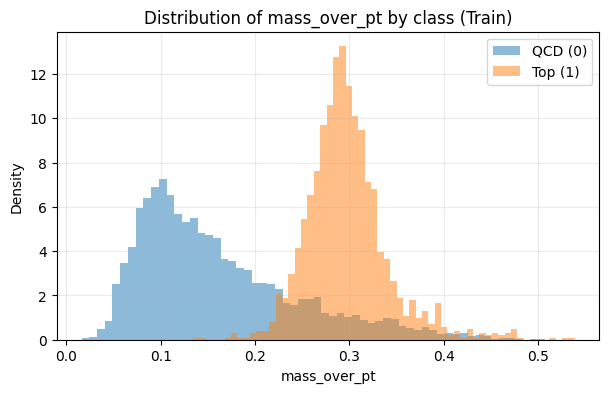

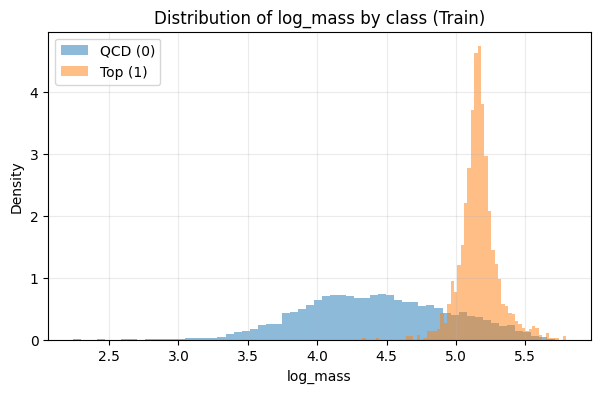

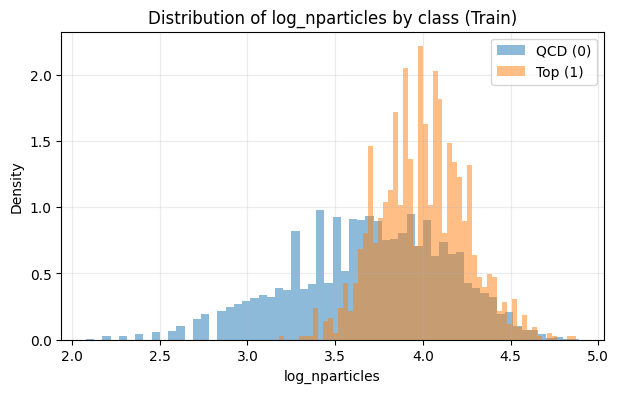

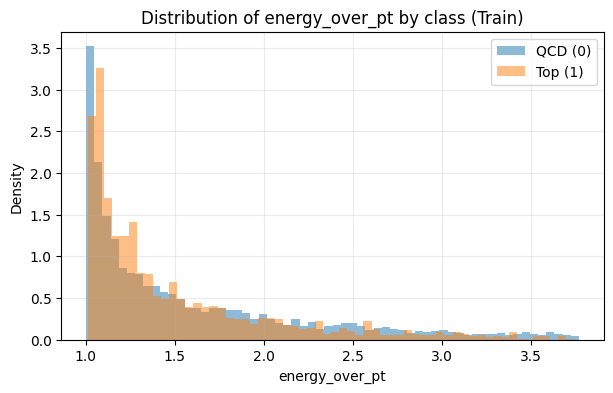

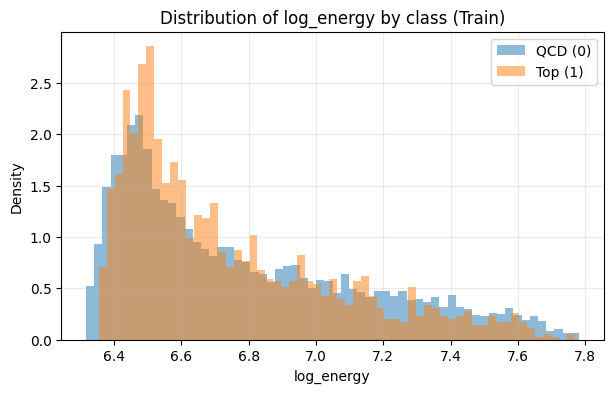

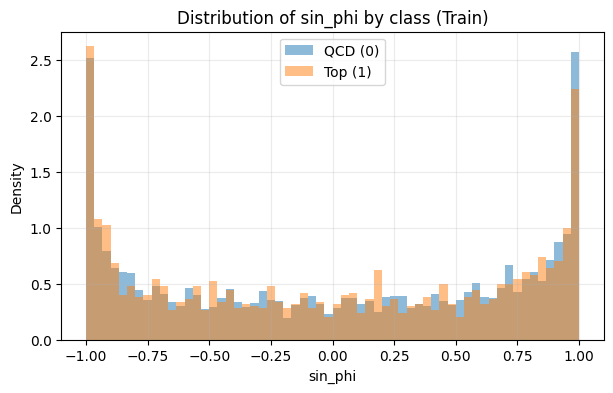

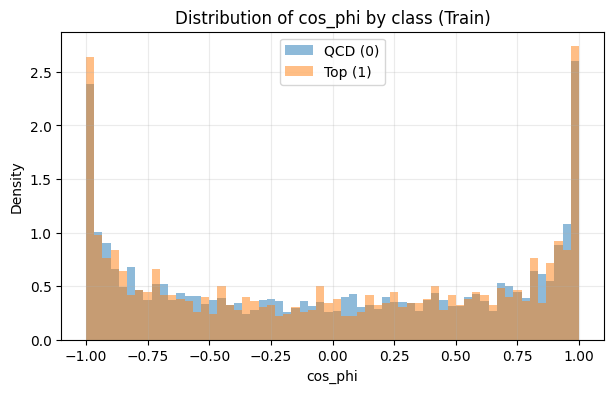

Engineered-feature ranking (Train):
          feature   roc_auc  spearman_rho
0    mass_over_pt  0.903733      0.556484
1        log_mass  0.902899      0.555334
2  log_nparticles  0.709603      0.288945
3      log_energy  0.520094     -0.027697
4  energy_over_pt  0.512232     -0.016860
5         sin_phi  0.509371     -0.012917
6         cos_phi  0.502820     -0.003887


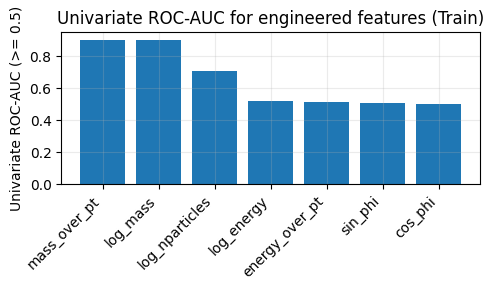

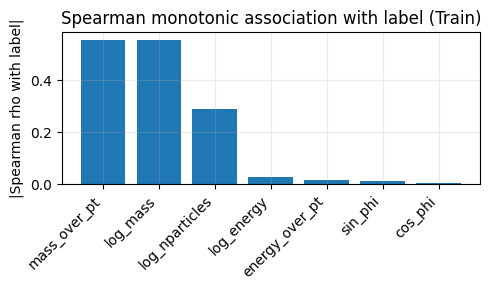

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

TARGET = "label"
eps = 1e-6


# Engineer ALL features

train3 = train.copy()

# Substructure engineered
train3["mass_over_pt"]     = train3["jet_mass"] / (train3["jet_pt"] + eps)
train3["log_mass"]         = np.log(train3["jet_mass"] + eps)
train3["log_nparticles"]   = np.log(train3["jet_nparticles"] + 1.0)

# Kinematics engineered
train3["energy_over_pt"]   = train3["jet_energy"] / (train3["jet_pt"] + eps)
train3["log_energy"]       = np.log(train3["jet_energy"] + eps)

# Angular encoding
train3["sin_phi"]          = np.sin(train3["jet_phi"])
train3["cos_phi"]          = np.cos(train3["jet_phi"])

ENGINEERED = [
    "mass_over_pt",
    "log_mass",
    "log_nparticles",
    "energy_over_pt",
    "log_energy",
    "sin_phi",
    "cos_phi",
]


# Distribution plots

def plot_distributions_by_class(df, features, target="label", bins=60):
    y = df[target].values
    for f in features:
        x0 = df.loc[y==0, f].values
        x1 = df.loc[y==1, f].values

        plt.figure(figsize=(7,4))
        plt.hist(x0, bins=bins, density=True, alpha=0.5, label="QCD (0)")
        plt.hist(x1, bins=bins, density=True, alpha=0.5, label="Top (1)")
        plt.title(f"Distribution of {f} by class (Train)")
        plt.xlabel(f)
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True, alpha=0.25)
        plt.show()

plot_distributions_by_class(train3, ENGINEERED, target=TARGET, bins=60)

# ROC-AUC + Spearman

y = train3[TARGET].values

rows = []
for f in ENGINEERED:
    x = train3[f].values

    # Univariate ROC-AUC (force >= 0.5)
    auc = roc_auc_score(y, x)
    auc = max(auc, 1 - auc)

    # Spearman corr with label
    rho = train3[[f, TARGET]].corr(method="spearman").iloc[0, 1]

    rows.append({"feature": f, "roc_auc": auc, "spearman_rho": rho})

results = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print("Engineered-feature ranking (Train):")
print(results)

# bar plot for ROC-AUC
plt.figure(figsize=(5,3))
plt.bar(results["feature"], results["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Univariate ROC-AUC (>= 0.5)")
plt.title("Univariate ROC-AUC for engineered features (Train)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# bar plot for Spearman (absolute value shows strength of monotonic trend)
plt.figure(figsize=(5,3))
plt.bar(results["feature"], results["spearman_rho"].abs())
plt.xticks(rotation=45, ha="right")
plt.ylabel("|Spearman rho with label|")
plt.title("Spearman monotonic association with label (Train)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# **Pytorch Dataset and Dataloader**

---

Here, I have also included the engineered features that later can be turned off or selectively choosen while using for model training. I am using all base features but also 4 engineered features for final model which I found that can give us better results based on their analysis I did earlier.

For example, mass/momentum gave us better univariate AUC-ROC as compared to just mass and momentum.


In [ ]:

# PyTorch Dataset + DataLoader
# Includes engineered features

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

TARGET = "label"
eps = 1e-6

# Feature engineering function
def add_engineered_features(df, eps=1e-6):
    df = df.copy()
    # Substructure engineered
    df["mass_over_pt"]     = df["jet_mass"] / (df["jet_pt"] + eps)
    df["log_mass"]         = np.log(df["jet_mass"] + eps)
    df["log_nparticles"]   = np.log(df["jet_nparticles"] + 1.0)

    # Kinematics engineered
    df["energy_over_pt"]   = df["jet_energy"] / (df["jet_pt"] + eps)
    df["log_energy"]       = np.log(df["jet_energy"] + eps)

    # Angular encoding
    df["sin_phi"]          = np.sin(df["jet_phi"])
    df["cos_phi"]          = np.cos(df["jet_phi"])
    return df


# Choose which feature set you want
BASE_FEATURES = ["jet_pt", "jet_eta", "jet_phi", "jet_energy", "jet_mass", "jet_nparticles"]

ENGINEERED_FEATURES = [
    "jet_pt", "jet_eta", "jet_energy", "jet_mass", "jet_nparticles",  # keep core (drop raw phi)
    "sin_phi", "cos_phi",
    "mass_over_pt", #"log_mass", #"log_nparticles",
    "energy_over_pt", #"log_energy",
]

USE_ENGINEERED = True  # <- switch to False if we want to use only base features


# Compute train-only normalization stats
def compute_train_stats(df_train, feature_cols):
    X = df_train[feature_cols].astype(np.float32).values
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    return {"mean": mean, "std": std}


# Dataset
class JetDataset(Dataset):
    def __init__(self, df, feature_cols, target_col="label", normalize=False, stats=None):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols

        X = self.df[feature_cols].astype(np.float32).values
        y = self.df[target_col].values

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

        if normalize:
            if stats is None:
                raise ValueError("normalize=True requires stats computed from TRAIN only.")
            mean = torch.tensor(stats["mean"], dtype=torch.float32)
            std  = torch.tensor(stats["std"], dtype=torch.float32)
            self.X = (self.X - mean) / (std + 1e-8)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Prepare splits
if USE_ENGINEERED:
    train_df = add_engineered_features(train, eps=eps)
    val_df   = add_engineered_features(val,   eps=eps)
    test_df  = add_engineered_features(test,  eps=eps)
    FEATURE_COLS = ENGINEERED_FEATURES
else:
    train_df, val_df, test_df = train.copy(), val.copy(), test.copy()
    FEATURE_COLS = BASE_FEATURES

# Train-only stats
stats = compute_train_stats(train_df, FEATURE_COLS)

# Datasets
train_ds = JetDataset(train_df, FEATURE_COLS, target_col=TARGET, normalize=True, stats=stats)
val_ds   = JetDataset(val_df,   FEATURE_COLS, target_col=TARGET, normalize=True, stats=stats)
test_ds  = JetDataset(test_df,  FEATURE_COLS, target_col=TARGET, normalize=True, stats=stats)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, drop_last=False)

# Sanity check
xb, yb = next(iter(train_loader))
print("Feature columns:", FEATURE_COLS)
print("Batch X:", xb.shape, "Batch y:", yb.shape)
print("Batch label counts:", torch.bincount(yb))


Feature columns: ['jet_pt', 'jet_eta', 'jet_energy', 'jet_mass', 'jet_nparticles', 'sin_phi', 'cos_phi', 'mass_over_pt', 'energy_over_pt']
Batch X: torch.Size([256, 9]) Batch y: torch.Size([256])
Batch label counts: tensor([204,  52])


# **Final Features for Model**

'jet_pt'

'jet_eta'

'jet_energy'

'jet_mass'

'jet_nparticles'

'sin_phi'

'cos_phi'

'mass_over_pt'

'energy_over_pt'

We are using engineered features, cos_phi and Sin_phi in place of jet_phi(original feature) and two two additional features that are mass over momentum and energy over momentum. So, final input features, are 9.

#  **Question : 02 - Model Implementation**

---



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

xb, yb = next(iter(train_loader))
input_dim = xb.shape[1]
print("input_dim =", input_dim, "| batch X =", xb.shape, "| batch y =", yb.shape)

input_dim = 9 | batch X = torch.Size([256, 9]) | batch y = torch.Size([256])


**Simpler Model:**

Input -> 64 -> 16 -> Output

In [ ]:
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, dropout_p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # (batch,)

model = SimpleMLP(input_dim, dropout_p=0.2).to(device)
model


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)

### **Loss and Optimizer (binary classification)**

---

#### **Loss function: Binary Cross-Entropy (BCE)**

Our task is **binary classification**:

- $$y=0$$ = QCD jet  
- $$y=1$$ = Top jet  

The network outputs a **logit** $$z$$ (raw score). We convert it to a probability with the sigmoid:

$$
p=\sigma(z)=\frac{1}{1+e^{-z}}.
$$

The **Binary Cross-Entropy** loss is:

$$
\mathcal{L}_{\mathrm{BCE}}(y,p)=-\Big[y\log(p)+(1-y)\log(1-p)\Big].
$$

**BCE in action**  
The key idea is: **being confidently wrong is heavily penalized**.

- If the true label is **Top** ( $$y=1$$ ):

  - Predict $$p=0.8$$:

  $$
  \mathcal{L}=-\log(0.8)\approx 0.223
  $$

  - Predict $$p=0.1$$ (confidently wrong):

  $$
  \mathcal{L}=-\log(0.1)\approx 2.303
  $$

  So the model is punished much more when it assigns a **low probability** to the true class.

- If the true label is **QCD** ( $$y=0$$ ):

  - Predict $$p=0.1$$:

  $$
  \mathcal{L}=-\log(1-0.1)=-\log(0.9)\approx 0.105
  $$

  - Predict $$p=0.9$$ (confidently wrong):

  $$
  \mathcal{L}=-\log(1-0.9)=-\log(0.1)\approx 2.303
  $$

Again, confident mistakes are punished strongly. This is exactly what we want: BCE provides a smooth, informative gradient that pushes the network toward correct probabilities.

---

#### **Why `BCEWithLogitsLoss` (PyTorch)**

Instead of applying sigmoid manually, we use `BCEWithLogitsLoss`, which combines sigmoid + BCE **in a numerically stable way**:

$$
\mathcal{L}(y,z)=-\Big[y\log(\sigma(z))+(1-y)\log\big(1-\sigma(z)\big)\Big].
$$

This avoids instability when $$z$$ is very large or very small (where $$\sigma(z)$$ can underflow/overflow).

---

#### **Class imbalance handling: `pos_weight`**

If the training set is imbalanced, we can weight the positive class (Top) more:

$$
\text{pos\_weight}=\frac{N_{\text{neg}}}{N_{\text{pos}}}.
$$

This penalizes mistakes on $$y=1$$ more strongly, helping prevent the model from ignoring the minority class.

---

#### **Optimizer: Adam**

After computing the loss, we update parameters to reduce it. Adam is popular because it combines:

- **Momentum** (smooths updates using past gradients)
- **Adaptive step sizes** (each parameter gets its own learning rate scaling)

In Adam, with gradient:

$$
g_t=\nabla_\theta \mathcal{L}_t,
$$

the moving averages are:

$$
m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2
$$

Bias correction:

$$
\hat m_t=\frac{m_t}{1-\beta_1^t},
\qquad
\hat v_t=\frac{v_t}{1-\beta_2^t}
$$

Update rule:

$$
\theta_{t+1}=\theta_t-\alpha\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}.
$$

**Adam in action**  
Assume one parameter $$\theta$$ and at step $$t=1$$ the gradient is $$g_1=0.5$$, with $$m_0=v_0=0$$, $$\beta_1=0.9$$, $$\beta_2=0.999$$:

$$
m_1=(1-\beta_1)g_1=0.1\times 0.5=0.05,
\qquad
v_1=(1-\beta_2)g_1^2=0.001\times 0.25=0.00025
$$

Bias-corrected:

$$
\hat m_1=\frac{0.05}{1-0.9}=0.5,
\qquad
\hat v_1=\frac{0.00025}{1-0.999}=0.25
$$

So the Adam step is roughly:

$$
\Delta\theta \approx \alpha\frac{0.5}{\sqrt{0.25}+\epsilon}\approx \alpha\cdot 1.
$$

This shows the intuition: Adam uses past gradients (via $$m_t$$) and normalizes by gradient scale (via $$v_t$$), giving **stable** and **well-scaled** updates.


In [ ]:
# pos weight
n_pos, n_neg = 0, 0
for _, yb in train_loader:
    n_pos += (yb == 1).sum().item()
    n_neg += (yb == 0).sum().item()

pos_weight_value = n_neg / max(n_pos, 1)
print("n_pos:", n_pos, "n_neg:", n_neg, "pos_weight:", pos_weight_value)

pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

n_pos: 1500 n_neg: 6106 pos_weight: 4.070666666666667


**Train/Eval epoch functions (loss + accuracy + AUCs)**

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    all_probs, all_y = [], []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).float()   # BCE needs float labels

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(yb)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_y.append(yb.detach().cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_y = np.concatenate(all_y)
    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_y.astype(int), preds)

    return total_loss / len(loader.dataset), acc


@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_probs, all_y = [], []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).float()

        logits = model(Xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * len(yb)

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_y.append(yb.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_y = np.concatenate(all_y)

    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_y.astype(int), preds)

    roc_auc = roc_auc_score(all_y, all_probs)
    pr_auc  = average_precision_score(all_y, all_probs)

    return total_loss / len(loader.dataset), acc, roc_auc, pr_auc


**Training loop + early stopping (based on val loss)**

In [ ]:
max_epochs = 200
patience = 15
min_delta = 1e-4

history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "val_roc_auc": [], "val_pr_auc": []
}

best_val_loss = np.inf
best_state = None
best_epoch = -1
no_improve = 0

for epoch in range(1, max_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, va_roc, va_pr = eval_one_epoch(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["val_roc_auc"].append(va_roc)
    history["val_pr_auc"].append(va_pr)

    if va_loss < best_val_loss - min_delta:
        best_val_loss = va_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
              f"val ROC-AUC {va_roc:.4f} PR-AUC {va_pr:.4f}")

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}. Best epoch = {best_epoch} (val loss {best_val_loss:.4f})")
        break

# Load best model
model.load_state_dict(best_state)
print("Loaded best model from epoch:", best_epoch)

Epoch   1 | train loss 1.0403 acc 0.6684 | val loss 0.9522 acc 0.7719 | val ROC-AUC 0.8662 PR-AUC 0.4715
Epoch   5 | train loss 0.5091 acc 0.8520 | val loss 0.4985 acc 0.8414 | val ROC-AUC 0.9133 PR-AUC 0.5617
Epoch  10 | train loss 0.4627 acc 0.8547 | val loss 0.4639 acc 0.8474 | val ROC-AUC 0.9265 PR-AUC 0.6224
Epoch  15 | train loss 0.4410 acc 0.8559 | val loss 0.4560 acc 0.8410 | val ROC-AUC 0.9322 PR-AUC 0.6565
Epoch  20 | train loss 0.4340 acc 0.8577 | val loss 0.4510 acc 0.8434 | val ROC-AUC 0.9365 PR-AUC 0.6842
Epoch  25 | train loss 0.4321 acc 0.8541 | val loss 0.4494 acc 0.8418 | val ROC-AUC 0.9390 PR-AUC 0.7007
Epoch  30 | train loss 0.4295 acc 0.8556 | val loss 0.4492 acc 0.8450 | val ROC-AUC 0.9406 PR-AUC 0.7132
Epoch  35 | train loss 0.4270 acc 0.8567 | val loss 0.4471 acc 0.8430 | val ROC-AUC 0.9417 PR-AUC 0.7216
Epoch  40 | train loss 0.4233 acc 0.8564 | val loss 0.4471 acc 0.8438 | val ROC-AUC 0.9424 PR-AUC 0.7263
Epoch  45 | train loss 0.4229 acc 0.8573 | val loss 0.4

**Plots: train/val loss and accuracy**

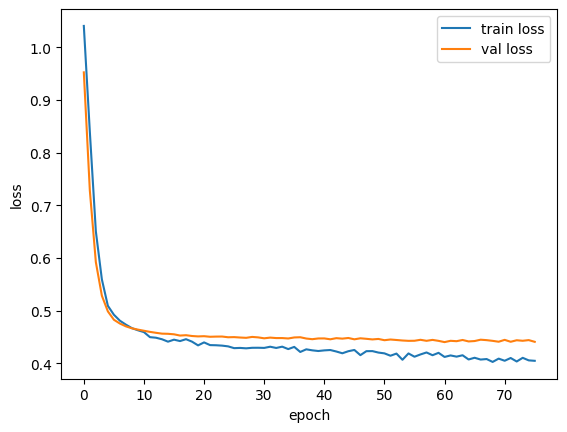

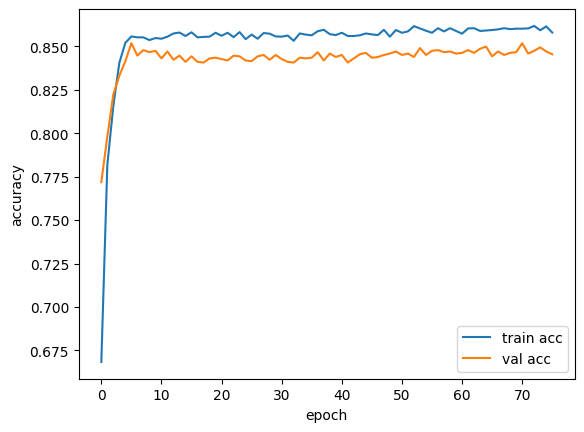

Best epoch: 61
Val accuracy at best epoch: 0.8461844197138315


In [ ]:
plt.figure()
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

print("Best epoch:", best_epoch)
print("Val accuracy at best epoch:", history["val_acc"][best_epoch-1])


# **Early Stopping Strategy**

We apply early stopping to prevent overfitting by monitoring the **validation loss**. In simple words, the validation loss is decreasing with increasing number of epochs but a point reaches when there is no imporvement in validation loss(model stops learning), So, we must stop otherwise we can get overfitting.

---
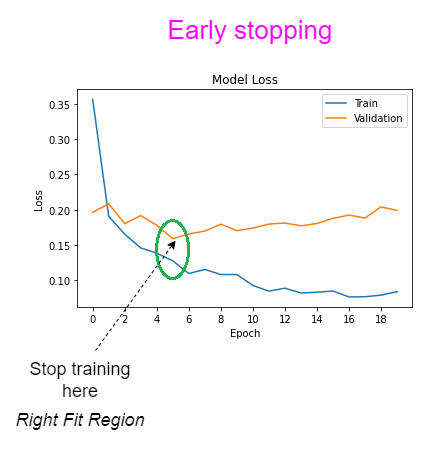
* **Monitored metric:** validation loss $$L_{\text{val}}$$

* **Improvement rule (min_delta):** an epoch is considered better only if  
  $$L_{\text{val}} < L_{\text{best}} - \Delta$$  
  where $$\Delta = 10^{-4}$$. This avoids reacting to tiny fluctuations.

* **Patience:** if no improvement occurs for **15** consecutive epochs, we stop:  
  $$\text{no_improve} \ge 15 \;\Rightarrow\; \text{stop training}$$

* **Checkpointing:** whenever validation loss improves, we save the model parameters $$\theta$$.  
  After stopping, we reload the best checkpoint $$\theta_{\text{best}}$$ (from the epoch with minimum $$L_{\text{val}}$$

The model stops on epoch 61.

**Evaluation Metrices(Test)**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs_all, y_all = [], []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        probs_all.append(probs)
        y_all.append(yb.numpy())
    return np.concatenate(probs_all), np.concatenate(y_all)

test_probs, test_y = predict_probs(model, test_loader)
test_pred = (test_probs >= 0.5).astype(int)

test_acc = accuracy_score(test_y.astype(int), test_pred)
test_roc = roc_auc_score(test_y.astype(int), test_probs)
test_pr  = average_precision_score(test_y.astype(int), test_probs)

print("TEST accuracy:", test_acc)
print("TEST ROC-AUC :", test_roc)
print("TEST PR-AUC  :", test_pr)

cm = confusion_matrix(test_y.astype(int), test_pred)
print("\nConfusion matrix (rows=true, cols=pred):\n", cm)

print("\nClassification report:\n")
print(classification_report(test_y.astype(int), test_pred, target_names=["QCD (0)", "Top (1)"]))


TEST accuracy: 0.895023520673434
TEST ROC-AUC : 0.9487582665754494
TEST PR-AUC  : 0.9204763697887633

Confusion matrix (rows=true, cols=pred):
 [[1707  327]
 [  97 1908]]

Classification report:

              precision    recall  f1-score   support

     QCD (0)       0.95      0.84      0.89      2034
     Top (1)       0.85      0.95      0.90      2005

    accuracy                           0.90      4039
   macro avg       0.90      0.90      0.89      4039
weighted avg       0.90      0.90      0.89      4039



### Test performance summary (numbers + interpretation)

This cell prints the main test metrics:

- **Accuracy ≈ 0.8950**: overall fraction correctly classified.
- **ROC-AUC ≈ 0.9488**: strong separation between Top vs QCD across all thresholds.
- **PR-AUC ≈ 0.9205**: high precision-recall quality for the positive class.

We will do separate analysis for each evaluation metric ahead.


In [ ]:
out_df = pd.DataFrame({
    "y_true": test_y.astype(int),
    "p_top": test_probs,
    "y_pred": test_pred
})

display(out_df.head(20))

for cls in [0, 1]:
    sub = out_df[out_df["y_true"] == cls]
    print(f"\nClass {cls}:")
    print("  count:", len(sub))
    print("  mean p_top:", sub["p_top"].mean())
    print("  predicted top rate (y_pred=1):", (sub["y_pred"] == 1).mean())


,y_true,p_top,y_pred
0,0,6.744836e-01,1
1,0,9.500804e-07,0
2,0,9.516547e-01,1
3,0,1.987203e-02,0
4,1,8.717781e-01,1
5,0,1.958808e-04,0
6,1,2.532575e-01,0
7,0,2.923297e-03,0
8,1,8.336582e-01,1
9,1,8.866673e-01,1



Class 0:
  count: 2034
  mean p_top: 0.14821255
  predicted top rate (y_pred=1): 0.1607669616519174

Class 1:
  count: 2005
  mean p_top: 0.8370399
  predicted top rate (y_pred=1): 0.9516209476309226


### Probability separation by class (sanity + calibration hint)

We compute statistics of predicted $$p(\text{Top})$$ separately for each true class:

- For **true QCD (0)**: mean $$p(\text{Top}) \approx 0.148$$ and predicted-Top rate $$\approx 0.161$$
- For **true Top (1)**: mean $$p(\text{Top}) \approx 0.837$$ and predicted-Top rate $$\approx 0.952$$

Interpretation:
- The means are far apart → the model outputs are well separated.
- The “predicted top rate” reflects the chosen threshold (default ~0.5).  
If we need fewer false positives (lower QCD contamination), we increase the threshold.


**ROC-AUC(Macro)**

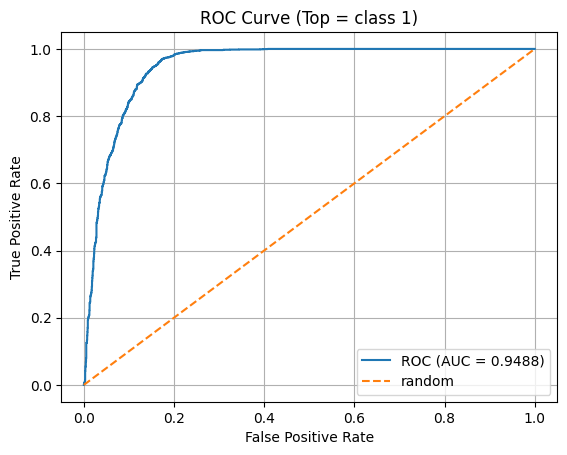

ROC-AUC (binary / macro): 0.9487582665754494


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

y_true = test_y.astype(int)
p1 = test_probs  # prob of class 1 (Top)

fpr, tpr, thresholds = roc_curve(y_true, p1)
roc_auc = roc_auc_score(y_true, p1)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Top = class 1)")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC (binary / macro):", roc_auc)


### ROC curve (threshold-free discrimination)

The ROC curve plots:
- \(x\): **False Positive Rate** \(= FP/(FP+TN)\)
- \(y\): **True Positive Rate / Recall** \(= TP/(TP+FN)\)

Results are good when FPR on X-axis approaches 0 and TPR on Y-axis approaches 1. The more the curve is towrads top left corner the better it is. AUC close to 1 indicates excellent discrimination.

Our **test ROC-AUC ≈ 0.9488**, meaning a randomly chosen Top jet is scored higher than a randomly chosen QCD jet about 95% of the time.




**Precision-Recall Curves**

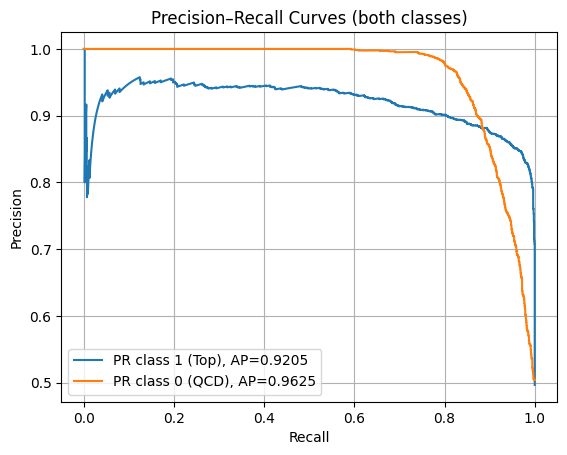

Average Precision (AP) class 1 (Top): 0.9204763697887633
Average Precision (AP) class 0 (QCD): 0.9624607440666201
Macro AP (mean of class 0 and class 1 AP): 0.9414685569276917


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_true = test_y.astype(int)
p1 = test_probs
p0 = 1.0 - p1

# ----- Class 1 (Top) PR -----
prec1, rec1, thr1 = precision_recall_curve(y_true, p1)
ap1 = average_precision_score(y_true, p1)

# ----- Class 0 (QCD) PR -----
y0 = 1 - y_true               # treat QCD as positive class
prec0, rec0, thr0 = precision_recall_curve(y0, p0)
ap0 = average_precision_score(y0, p0)

# Plot both PR curves
plt.figure()
plt.plot(rec1, prec1, label=f"PR class 1 (Top), AP={ap1:.4f}")
plt.plot(rec0, prec0, label=f"PR class 0 (QCD), AP={ap0:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves (both classes)")
plt.legend()
plt.grid(True)
plt.show()

print("Average Precision (AP) class 1 (Top):", ap1)
print("Average Precision (AP) class 0 (QCD):", ap0)

# Macro AP
print("Macro AP (mean of class 0 and class 1 AP):", (ap0 + ap1) / 2)


### Precision–Recall curves (both classes) — with values

We plot PR curves for:
- **Class 1 (Top as positive)** using $$p(\text{Top})$$
- **Class 0 (QCD as positive)** using $$p(\text{QCD}) = 1 - p(\text{Top})$$

**Average Precision (AP)** (area under the PR curve) from our test predictions:
- **AP (Top, class 1)** $$\approx 0.9205$$
- **AP (QCD, class 0)** $$\approx 0.9625$$
- **Macro AP (mean of both)** $$\approx 0.9415$$

**Interpretation**
- The model’s PR performance is **excellent for both classes** (AP close to 1 is ideal).
- **QCD has higher AP ($$\approx 0.9625$$)** → when QCD is treated as the positive label, the model ranks QCD events more cleanly across thresholds (fewer ambiguous QCD cases).
- **Top has slightly lower AP ($$\approx 0.9205$$)** → Top remains very well separated overall, but achieving very high Top recall tends to admit more **false positives** (QCD predicted as Top), which reduces precision at some operating points.

---

**Connection to the confusion matrix (threshold = 0.5)**  
At the default threshold, we had $$TP=1908,\ FP=327,\ FN=97,\ TN=1707,$$ so:

- **Precision (Top)**:
$$
\frac{TP}{TP+FP} =
\frac{1908}{1908+327} =
\frac{1908}{2235} \approx 0.854
$$

- **Recall (Top)**:
$$
\frac{TP}{TP+FN} =
\frac{1908}{1908+97} =
\frac{1908}{2005} \approx 0.952
$$

This matches the PR story: **very high recall**, with precision reduced mainly by **FP contamination**.


**Confusion Matrix**

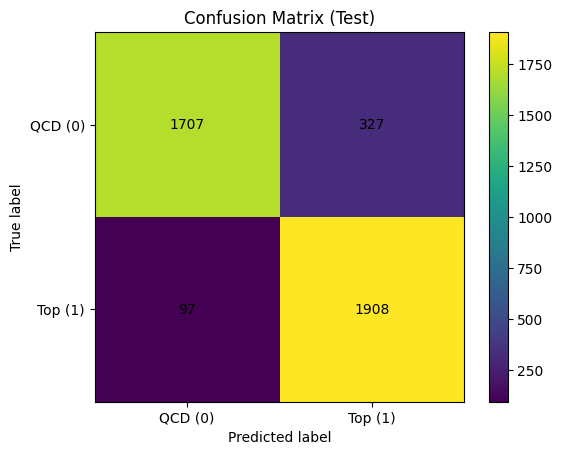

Confusion matrix (rows=true, cols=pred):
 [[1707  327]
 [  97 1908]]


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

y_true = test_y.astype(int)
y_pred = test_pred.astype(int)

cm = confusion_matrix(y_true, y_pred)  # rows=true, cols=pred

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["QCD (0)", "Top (1)"])
plt.yticks([0, 1], ["QCD (0)", "Top (1)"])

# write values inside cells
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

print("Confusion matrix (rows=true, cols=pred):\n", cm)



$$
\begin{bmatrix}
TN & FP\\
FN & TP
\end{bmatrix}
=
\begin{bmatrix}
1707 & 327\\
97 & 1908
\end{bmatrix}
$$

Key takeaways:
- **Top recall** is high:
$$
\frac{TP}{TP+FN}=\frac{1908}{1908+97}=\frac{1908}{2005}\approx 0.952
$$
so we detect most Top jets.

- **QCD recall (specificity)** is lower:
$$
\frac{TN}{TN+FP}=\frac{1707}{1707+327}=\frac{1707}{2034}\approx 0.839
$$
so some QCD jets are misclassified as Top.

- This trade-off is controlled by the **probability threshold** (explored via ROC/PR curves).



**Predicted Probability Distribution by true label**

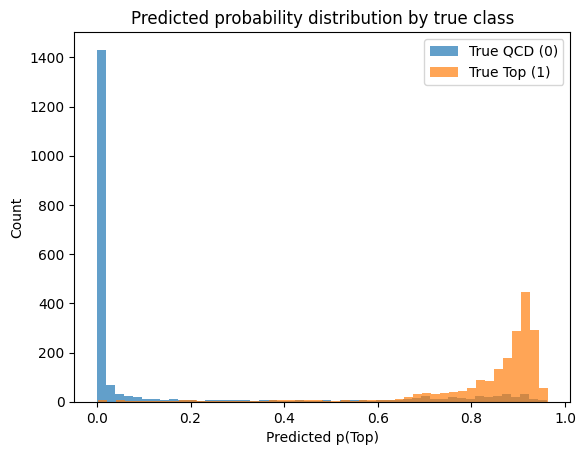

In [ ]:
import matplotlib.pyplot as plt

y_true = test_y.astype(int)
p1 = test_probs

plt.figure()
plt.hist(p1[y_true==0], bins=50, alpha=0.7, label="True QCD (0)")
plt.hist(p1[y_true==1], bins=50, alpha=0.7, label="True Top (1)")
plt.xlabel("Predicted p(Top)")
plt.ylabel("Count")
plt.title("Predicted probability distribution by true class")
plt.legend()
plt.show()


### Predicted probability distributions by true label

The histogram shows clear separation between classes: for **true QCD (0)** the scores concentrate near zero with mean $$\overline{p(\text{Top})}\approx 0.1482$$, and at threshold $$t=0.5$$ the fraction misclassified as Top is
$$
\Pr\!\big(p(\text{Top})\ge 0.5\mid y=0\big)=\frac{FP}{TN+FP}=\frac{327}{2034}\approx 0.161.
$$
For **true Top (1)** the scores concentrate at high values with mean $$\overline{p(\text{Top})}\approx 0.8370$$, and at $$t=0.5$$ the selected-as-Top fraction is
$$
\Pr\!\big(p(\text{Top})\ge 0.5\mid y=1\big)=\frac{TP}{TP+FN}=\frac{1908}{2005}\approx 0.952.
$$
The small overlap region (where the blue tail meets the orange distribution) contains ambiguous jets; increasing $$t$$ reduces false positives (QCD contamination) but increases false negatives (missed Top jets).


In [ ]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

@torch.no_grad()
def predict_probs_from_arrays(model, X_np, batch_size=1024):
    model.eval()
    probs = []
    for i in range(0, len(X_np), batch_size):
        xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32).to(device)
        logits = model(xb)
        pb = torch.sigmoid(logits).detach().cpu().numpy()
        probs.append(pb)
    return np.concatenate(probs)

def eval_auc(model, X_np, y_np):
    p = predict_probs_from_arrays(model, X_np)
    return roc_auc_score(y_np.astype(int), p)


In [ ]:
import pandas as pd

# Use your already-prepared normalized val tensors inside val_ds
X_val_np = val_ds.X.numpy()
y_val_np = val_ds.y.numpy()

baseline_auc = eval_auc(model, X_val_np, y_val_np)
print("Baseline VAL ROC-AUC:", baseline_auc)

importances = []
rng = np.random.default_rng(42)

for j, feat in enumerate(FEATURE_COLS):
    X_perm = X_val_np.copy()
    perm_idx = rng.permutation(len(X_perm))
    X_perm[:, j] = X_perm[perm_idx, j]  # shuffle ONLY feature j

    perm_auc = eval_auc(model, X_perm, y_val_np)
    drop = baseline_auc - perm_auc
    importances.append(drop)

imp_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "auc_drop": importances
}).sort_values("auc_drop", ascending=False)

imp_df.head(15)


Baseline VAL ROC-AUC: 0.9449799220549717


,feature,auc_drop
3,jet_mass,0.208788
7,mass_over_pt,0.150444
4,jet_nparticles,0.031801
2,jet_energy,0.003455
6,cos_phi,0.002428
0,jet_pt,0.001975
1,jet_eta,0.000100
8,energy_over_pt,0.000007
5,sin_phi,-0.001198


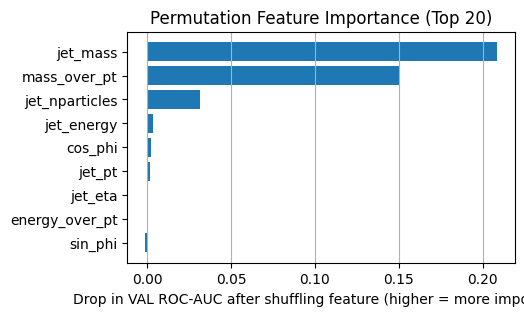

In [ ]:
import matplotlib.pyplot as plt

top_k = 20
plot_df = imp_df.head(top_k).iloc[::-1]  # reverse for nicer plot

plt.figure(figsize=(5, 3))
plt.barh(plot_df["feature"], plot_df["auc_drop"])
plt.xlabel("Drop in VAL ROC-AUC after shuffling feature (higher = more important)")
plt.title(f"Permutation Feature Importance (Top {top_k})")
plt.grid(True, axis="x")
plt.show()


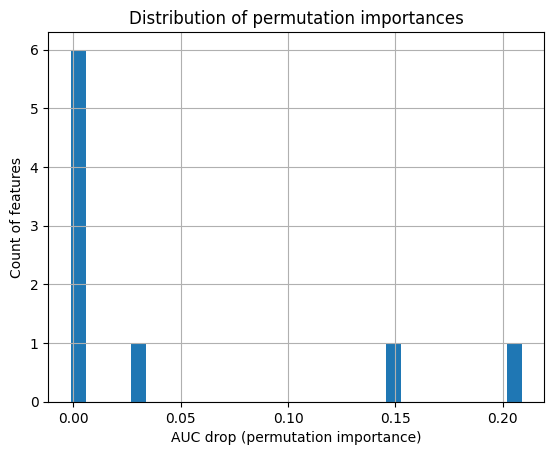

In [ ]:
plt.figure()
plt.hist(imp_df["auc_drop"], bins=30)
plt.xlabel("AUC drop (permutation importance)")
plt.ylabel("Count of features")
plt.title("Distribution of permutation importances")
plt.grid(True)
plt.show()

### Permutation feature importance (validation-based)

Goal: estimate which features the trained model *really uses*.

Procedure:
1. Compute **baseline VAL ROC-AUC** (here ≈ **0.9450**).
2. For each feature \(j\):
   - randomly shuffle that column (break its association with the label),
   - recompute VAL ROC-AUC,
   - define **importance = baseline_auc − permuted_auc**.

Interpretation:
- Larger **AUC drop** → feature is more important for discrimination.
- Near-zero drop → feature contributes little (or is redundant with others).

We visualize:
- a **Top-K bar plot** (most important features),
- a **histogram** of AUC drops (overall importance spread).




*   **The mass of pt shows highest importance greater than individual mass or momentum feature. This also adds why I used engineered features.**



# **Hyperparameter Optimization (Optional)**

---

So far, we selected the network architecture and training settings **manually** (e.g., hidden units, dropout, learning rate, and L2 regularization/weight decay). However, there may exist a better combination of these hyperparameters that improves performance. To explore this systematically, we use **Optuna** and optimize a target metric such as **ROC--AUC** on the validation set.

**What Optuna does.**  
Optuna automatically proposes different hyperparameter combinations (within ranges that we define), trains the model, evaluates the chosen metric (here, AUC), and then uses previous trial results to suggest better candidates. In other words, it performs an efficient search for hyperparameters that **maximize** the objective, without us having to manually try many settings.

**Why not Grid Search or Random Search?**  
Grid search becomes expensive very quickly because it evaluates all combinations on a fixed grid. Random search is cheaper but can waste many trials in unpromising regions. Optuna is typically more computationally efficient because it uses **adaptive search** based on past outcomes.

In this notebook, we tune the following hyperparameters:
- **Learning rate**
- **Weight decay** (L2 regularization)
- **Dropout rate**
- **Number of neurons in the hidden layer(s)**


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
import torch
import torch.nn as nn
from copy import deepcopy

# Reproducibility helpers
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

print("Device:", device)

Device: cpu


In [ ]:
# Use the same baseline loss style as we did before

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
print("Using BCEWithLogitsLoss with pos_weight:", float(pos_weight.cpu().item()))


Using BCEWithLogitsLoss with pos_weight: 4.070666790008545


In [ ]:
class TunableMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # logits shape (N,)

def build_baseline_model(trial, input_dim: int):
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
    dropout    = trial.suggest_float("dropout", 0.0, 0.5)
    model = TunableMLP(input_dim=input_dim, hidden_dim=hidden_dim, dropout=dropout)
    return model


In [ ]:
from sklearn.metrics import roc_auc_score

def objective(trial):
    set_seed(42)  # keep comparable trials

    input_dim = len(FEATURE_COLS)

    model = build_baseline_model(trial, input_dim).to(device)

    lr           = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Early stopping on VAL loss, but we *optimize* VAL ROC-AUC
    max_epochs = 80
    patience   = 10
    min_delta  = 1e-4

    best_val_loss = np.inf
    best_state = None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_roc, val_pr = eval_one_epoch(model, val_loader, criterion)

        # report ROC-AUC to Optuna
        trial.report(val_roc, step=epoch)

        # pruning
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # early stopping tracking by val loss
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # load best checkpoint for fair evaluation
    if best_state is not None:
        model.load_state_dict(best_state)

    # Compute VAL ROC-AUC again using probabilities
    val_probs, val_y = predict_probs(model, val_loader)
    val_probs = val_probs.reshape(-1).astype(float)
    val_y     = val_y.reshape(-1).astype(int)

    val_auc = roc_auc_score(val_y, val_probs)
    return val_auc

In [ ]:
sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=10)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best VAL ROC-AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2026-01-16 14:26:02,640] A new study created in memory with name: no-name-75d6768b-ed91-4433-b721-566cb7b97bbf


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-16 14:26:34,744] Trial 0 finished with value: 0.9398588626968349 and parameters: {'hidden_dim': 64, 'dropout': 0.07800932022121826, 'lr': 0.00018408992080552527, 'weight_decay': 1.7073967431528095e-07}. Best is trial 0 with value: 0.9398588626968349.
[I 2026-01-16 14:26:57,352] Trial 1 finished with value: 0.9440273044274039 and parameters: {'hidden_dim': 32, 'dropout': 0.48495492608099716, 'lr': 0.002595942550311264, 'weight_decay': 7.068974950624599e-07}. Best is trial 1 with value: 0.9440273044274039.
[I 2026-01-16 14:27:10,042] Trial 2 finished with value: 0.9439641910442109 and parameters: {'hidden_dim': 256, 'dropout': 0.21597250932105788, 'lr': 0.0003124565071260876, 'weight_decay': 2.8016351587162606e-05}. Best is trial 1 with value: 0.9440273044274039.
[I 2026-01-16 14:27:26,803] Trial 3 finished with value: 0.9426743112752058 and parameters: {'hidden_dim': 256, 'dropout': 0.3925879806965068, 'lr': 0.00021839352923182988, 'weight_decay': 1.1400863701127326e-05}. Bes

# **Optimized Parameters**


---


The optimized parameters are now,

Hidden Layer = 128 Neurons(Train data -> 128 -> 64 -> Output)

L2 Regularization = 9.74471e-05

Learning Rate = 0.001995

Dropout = 0.001813

In [ ]:
best_params = study.best_params

set_seed(42)
input_dim = len(FEATURE_COLS)

# Build final tuned baseline model
model = TunableMLP(
    input_dim=input_dim,
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"]
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

max_epochs = 120
patience   = 15
min_delta  = 1e-4

best_val_loss = np.inf
best_state = None
best_epoch = -1
no_improve = 0

history = {"train_loss": [], "val_loss": [], "val_roc_auc": [], "val_pr_auc": []}

for epoch in range(1, max_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, va_roc, va_pr = eval_one_epoch(model, val_loader, criterion)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["val_roc_auc"].append(va_roc)
    history["val_pr_auc"].append(va_pr)

    if va_loss < best_val_loss - min_delta:
        best_val_loss = va_loss
        best_state = deepcopy(model.state_dict())
        best_epoch = epoch
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            break

# Load best checkpoint
if best_state is not None:
    model.load_state_dict(best_state)

print("Best epoch:", best_epoch)
print("Best VAL loss:", best_val_loss)


Best epoch: 19
Best VAL loss: 0.43735223340495405


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

# Predict probabilities
test_probs, test_y = predict_probs(model, test_loader)
test_probs = test_probs.reshape(-1).astype(float)
test_y     = test_y.reshape(-1).astype(int)

# Default threshold 0.5
test_pred = (test_probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(test_y, test_pred).ravel()

test_acc  = (tp + tn) / (tp + tn + fp + fn)
test_auc  = roc_auc_score(test_y, test_probs)
test_ap   = average_precision_score(test_y, test_probs)

print(f"TEST Acc = {test_acc:.4f}")
print(f"TEST ROC-AUC = {test_auc:.4f}")
print(f"TEST PR-AUC (AP) = {test_ap:.4f}")

print("\nConfusion matrix [[TN, FP],[FN, TP]]:")
print([[tn, fp], [fn, tp]])

print("\nClassification report:")
print(classification_report(test_y, test_pred, digits=4))

TEST Acc = 0.8950
TEST ROC-AUC = 0.9496
TEST PR-AUC (AP) = 0.9270

Confusion matrix [[TN, FP],[FN, TP]]:
[[np.int64(1724), np.int64(310)], [np.int64(114), np.int64(1891)]]

Classification report:
              precision    recall  f1-score   support

           0     0.9380    0.8476    0.8905      2034
           1     0.8592    0.9431    0.8992      2005

    accuracy                         0.8950      4039
   macro avg     0.8986    0.8954    0.8948      4039
weighted avg     0.8988    0.8950    0.8948      4039



In [ ]:
from sklearn.metrics import roc_curve

target_fpr = 0.05

# VAL probs
val_probs, val_y = predict_probs(model, val_loader)
val_probs = val_probs.reshape(-1).astype(float)
val_y     = val_y.reshape(-1).astype(int)

fpr, tpr, thresholds = roc_curve(val_y, val_probs)

ok = np.where(fpr <= target_fpr)[0]
best_idx = ok[np.argmax(tpr[ok])]
thr_star = thresholds[best_idx]

print("Chosen threshold from VAL:", float(thr_star))
print(f"VAL @ thr*: FPR={float(fpr[best_idx]):.4f}, TPR={float(tpr[best_idx]):.4f}")

# TEST check
test_pred_thr = (test_probs >= thr_star).astype(int)
tn, fp, fn, tp = confusion_matrix(test_y, test_pred_thr).ravel()

test_fpr = fp / (fp + tn)
test_tpr = tp / (tp + fn)

print("\nTEST confusion matrix [[TN, FP],[FN, TP]]:")
print([[tn, fp], [fn, tp]])

print(f"TEST @ thr*: FPR={test_fpr:.4f} (must be <= {target_fpr}), TPR={test_tpr:.4f}")

Chosen threshold from VAL: 0.862768828868866
VAL @ thr*: FPR=0.0492, TPR=0.6171

TEST confusion matrix [[TN, FP],[FN, TP]]:
[[np.int64(1955), np.int64(79)], [np.int64(812), np.int64(1193)]]
TEST @ thr*: FPR=0.0388 (must be <= 0.05), TPR=0.5950


### **QCD Contamination Restriction**

---



This shows the restriction of FPR to be less than or equal to 5 percent and resulting True positive rate.

**The TPR@(FPR <= 0.05) = 0.5950**

We tune the threshold on validation data and then use this threshold on test data to get TPR at this condition.

/tmp/ipython-input-3694480734.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipython-input-3694480734.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

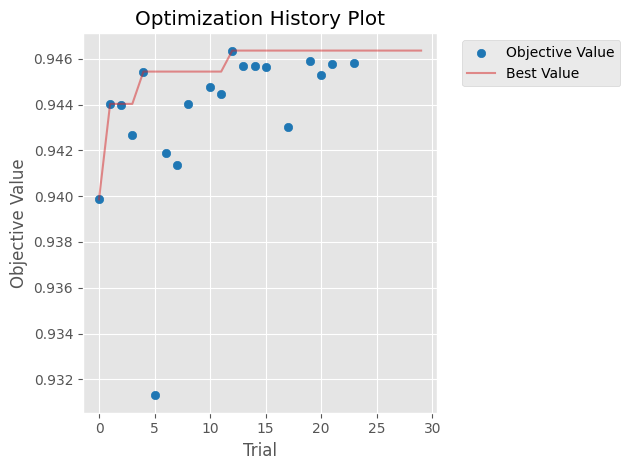

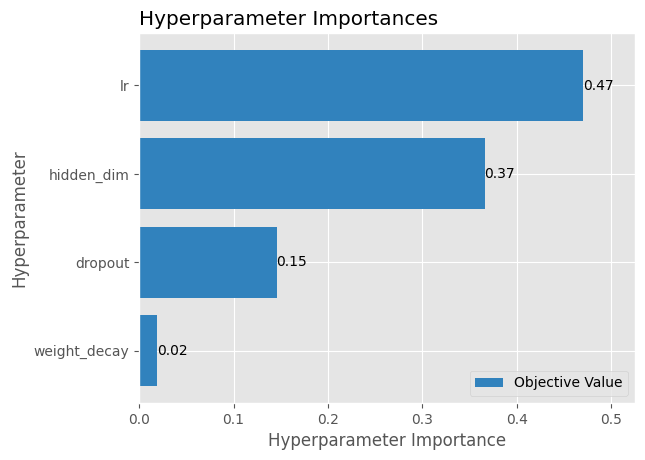

In [ ]:
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)

## **Optuna summary (what we achieved)**

Up to this point, we trained a **simple baseline MLP (non-tuned)** and computed all required metrics and probability outputs on the validation/test sets.  
**This baseline model will remain our reference point**, and later (in the Data Augmentation section) we will compare the augmented model **against this same baseline** to keep the comparison fair (same features, same splits, same evaluation).

---

### **Why we ran Optuna**
The baseline model uses manually chosen hyperparameters (hidden units, dropout, learning rate, weight decay). To systematically explore whether a better combination exists, we ran **Optuna** to search for hyperparameters that maximize validation ROC--AUC:
$$
\text{maximize } \mathrm{AUC}_{\text{val}}.
$$

We tuned:
- **Learning rate**
- **Weight decay (L2 regularization)**
- **Dropout**
- **Hidden layer size**

---

### **What Optuna improved (numbers)**
Optuna found a configuration that improves ranking metrics compared to the baseline.

- **Baseline (non-tuned):**  
  Accuracy $$\approx 0.8950$$, ROC--AUC $$\approx 0.9488$$, PR--AUC $$\approx 0.9205$$

- **Optuna-tuned (optional):**  
  Accuracy $$\approx 0.8950$$, ROC--AUC $$\approx 0.9496$$, PR--AUC $$\approx 0.9270$$

So the improvements are:
$$
\Delta \mathrm{Accuracy} \approx 0.8950 - 0.8950 = 0.0000,
$$
$$
\Delta \mathrm{ROC\text{--}AUC} \approx 0.9496 - 0.9488 = 0.0008,
$$
$$
\Delta \mathrm{PR\text{--}AUC} \approx 0.9270 - 0.9205 = 0.0065.
$$

This shows that even with the same overall model family, **hyperparameter search can push performance upward**, mainly visible in ROC--AUC and especially PR--AUC (accuracy stays essentially unchanged).

---

### **Optuna plots**
- **Optimization history:** shows the best validation AUC found so far as the number of trials increases.  
  An upward trend indicates Optuna is successfully discovering better hyperparameters over time.

- **Hyperparameter importance:** ranks which hyperparameters most strongly affect validation AUC.  
  Higher importance means that parameter has a larger impact on model performance (e.g., learning rate often dominates).

---

### **Important clarification for the next sections**
Even though Optuna improves results, for the **augmentation comparison** we will use the **original non-tuned baseline model** (because its probabilities/metrics are already computed and it provides the cleanest reference point).  
Optuna is included here as an **optional improvement step** that demonstrates additional gains are possible through tuning.


# **Question : 03 - Computing Epistemic Uncertainty**

---



**Epistemic vs Aleatoric**  
Epistemic uncertainty reflects **model uncertainty** due to limited data/knowledge and can be reduced with more training data or a better model. In contrast, aleatoric uncertainty comes from **intrinsic noise** in the measurements and cannot be removed by collecting more data.

**Why ensemble variance captures epistemic uncertainty.**  
Training the same model multiple times with different random seeds gives multiple plausible solutions. If these solutions disagree on a sample, it indicates uncertainty in the learned decision function, so we quantify epistemic uncertainty as:
$$
u_i=\mathrm{Var}_{k=1..K}\big(p_i^{(k)}\big).
$$

**How we compare uncertainty across models.**  
Uncertainty is computed per sample, but we summarize it into a comparable scalar by measuring how well it predicts mistakes *(Our Computed number)* :
$$
\mathrm{AUROC}_{\text{wrong-detection}} \approx 0.815.
$$
Higher AUROC means uncertainty is more informative for identifying likely errors.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, roc_curve, auc

# Sanity checks
assert "train_loader" in globals() and "val_loader" in globals() and "test_loader" in globals()
assert "device" in globals()
assert "input_dim" in globals()
assert "SimpleMLP" in globals()


In [ ]:
def set_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# compute pos_weight from train_loader
n_pos, n_neg = 0, 0
for _, yb in train_loader:
    yb = yb.view(-1)
    n_pos += (yb == 1).sum().item()
    n_neg += (yb == 0).sum().item()

pos_weight_value = n_neg / max(n_pos, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

criterion_q3 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print("pos_weight:", pos_weight_value, "| n_pos:", n_pos, "| n_neg:", n_neg)


def train_one_epoch_q3(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).float().view(-1)

        optimizer.zero_grad()
        logits = model(Xb).view(-1)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_loss_q3(model, loader, criterion):
    model.eval()
    total_loss = 0.0

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).float().view(-1)
        logits = model(Xb).view(-1)
        loss = criterion(logits, yb)
        total_loss += loss.item() * yb.size(0)

    return total_loss / len(loader.dataset)


pos_weight: 4.070666666666667 | n_pos: 1500 | n_neg: 6106


In [ ]:
def train_single_model_q3(seed=0, epochs=30, lr=1e-3, weight_decay=1e-5, patience=6):
    set_seed(seed)
    model = SimpleMLP(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch_q3(model, train_loader, criterion_q3, optimizer)
        va_loss = eval_loss_q3(model, val_loader, criterion_q3)

        if va_loss < best_val_loss - 1e-6:
            best_val_loss = va_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


K = 5
ensemble_models = []
val_losses = []

for k in range(K):
    m, best_va = train_single_model_q3(seed=123 + k, epochs=40, patience=7)
    ensemble_models.append(m)
    val_losses.append(best_va)
    print(f"Model {k+1}/{K} best val loss: {best_va:.5f}")

print("Val losses:", val_losses)


Model 1/5 best val loss: 0.44848
Model 2/5 best val loss: 0.44002
Model 3/5 best val loss: 0.44808
Model 4/5 best val loss: 0.44352
Model 5/5 best val loss: 0.44027
Val losses: [0.4484750772034231, 0.44002399526074504, 0.4480773243691849, 0.44352348160667904, 0.4402733254224204]


In [ ]:
def binary_entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(p*np.log(p) + (1-p)*np.log(1-p))

@torch.no_grad()
def ensemble_predict_q3(models, loader):
    ys, p_means, p_vars, mis = [], [], [], []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.view(-1).cpu().numpy().astype(int)

        probs_list = []
        for m in models:
            m.eval()
            logits = m(Xb).view(-1)
            probs_list.append(torch.sigmoid(logits).cpu().numpy())

        probs_stack = np.stack(probs_list, axis=0)     # (K, batch)
        p_mean = probs_stack.mean(axis=0)              # (batch,)
        p_var  = probs_stack.var(axis=0)               # (batch,)

        # Mutual Information
        H_mean = binary_entropy(p_mean)
        H_each = binary_entropy(probs_stack)           # (K, batch)
        MI = H_mean - H_each.mean(axis=0)

        ys.append(yb)
        p_means.append(p_mean)
        p_vars.append(p_var)
        mis.append(MI)

    y = np.concatenate(ys)
    p_mean = np.concatenate(p_means)
    epi_var = np.concatenate(p_vars)
    epi_mi = np.concatenate(mis)
    return y, p_mean, epi_var, epi_mi


y_test, p_mean_test, epi_var_test, epi_mi_test = ensemble_predict_q3(ensemble_models, test_loader)

pred_test = (p_mean_test >= 0.5).astype(int)
print("Test accuracy:", accuracy_score(y_test, pred_test))
print("Test ROC-AUC :", roc_auc_score(y_test, p_mean_test))
print("Test PR-AUC  :", average_precision_score(y_test, p_mean_test))


Test accuracy: 0.8942807625649913
Test ROC-AUC : 0.9460461432456225
Test PR-AUC  : 0.9172625366344902


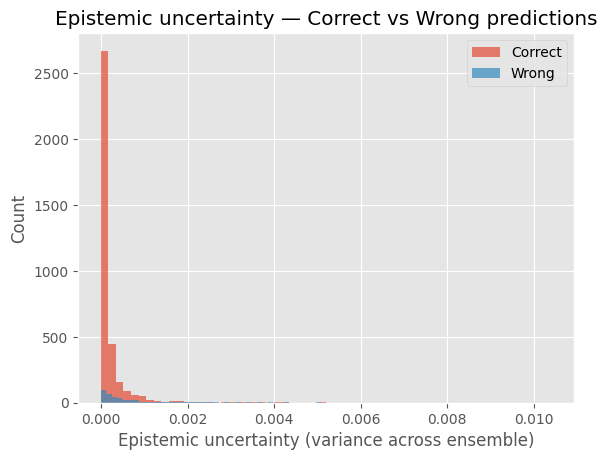

In [ ]:
correct = (pred_test == y_test)

plt.figure()
plt.hist(epi_var_test[correct], bins=60, alpha=0.7, label="Correct")
plt.hist(epi_var_test[~correct], bins=60, alpha=0.7, label="Wrong")
plt.xlabel("Epistemic uncertainty (variance across ensemble)")
plt.ylabel("Count")
plt.title("Epistemic uncertainty — Correct vs Wrong predictions")
plt.legend()
plt.show()


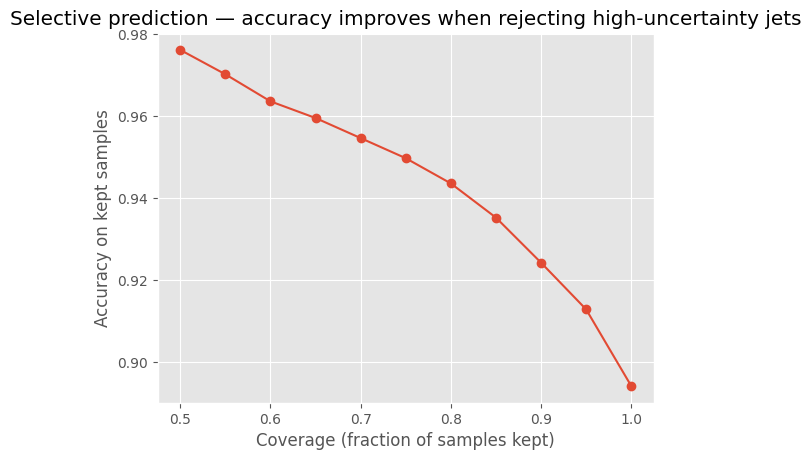

In [ ]:
def accuracy_vs_coverage(y, p_mean, uncertainty, coverages=np.linspace(0.5, 1.0, 11)):
    pred = (p_mean >= 0.5).astype(int)
    order = np.argsort(uncertainty)  # keep lowest uncertainty first

    y_sorted = y[order]
    pred_sorted = pred[order]

    accs = []
    for c in coverages:
        n_keep = int(len(y) * c)
        accs.append(accuracy_score(y_sorted[:n_keep], pred_sorted[:n_keep]))
    return coverages, np.array(accs)

coverages = np.linspace(0.5, 1.0, 11)
cov, accs = accuracy_vs_coverage(y_test, p_mean_test, epi_var_test, coverages)

plt.figure()
plt.plot(cov, accs, marker="o")
plt.xlabel("Coverage (fraction of samples kept)")
plt.ylabel("Accuracy on kept samples")
plt.title("Selective prediction — accuracy improves when rejecting high-uncertainty jets")
plt.show()


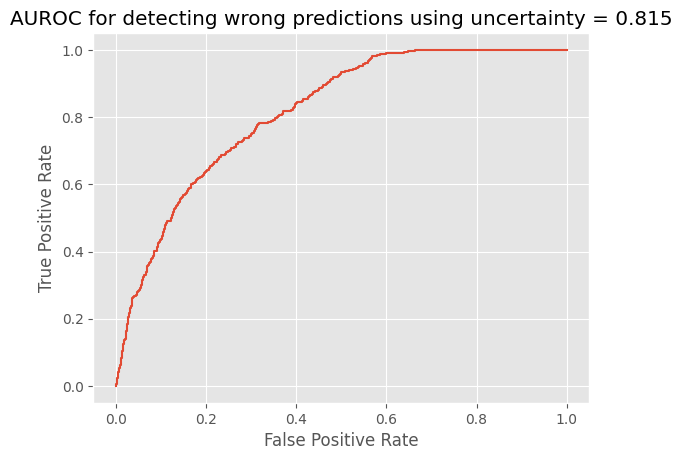

AUROC(wrong detection) using epistemic uncertainty: 0.8152729257925053


In [ ]:
is_wrong = (pred_test != y_test).astype(int)
scores = epi_var_test

fpr, tpr, _ = roc_curve(is_wrong, scores)
auroc_wrong = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"AUROC for detecting wrong predictions using uncertainty = {auroc_wrong:.3f}")
plt.show()

print("AUROC(wrong detection) using epistemic uncertainty:", auroc_wrong)


### Epistemic uncertainty estimation

We estimate **epistemic uncertainty** (model uncertainty due to limited knowledge/data) using an **ensemble-based approach**: we train the same MLP multiple times (different random initializations / data shuffling) and, for each test sample $$i$$, collect the predicted probabilities $$\{p_i^{(k)}\}_{k=1}^K$$. The epistemic uncertainty is then quantified by the **variance across the ensemble**:
$$
u_i = \mathrm{Var}_{k=1..K}\big(p_i^{(k)}\big).
$$
This choice is appropriate because epistemic uncertainty should be **high when the model is not consistent across plausible parameter settings**, and ensembling directly captures that disagreement.

### What the results show (linking to the 3 plots)

Most **correct predictions** have very low uncertainty (a large spike near $$u \approx 0$$), while **wrong predictions** are shifted toward higher uncertainty values (top histogram), meaning the model tends to be less consistent on mistakes. Using uncertainty as a score to detect errors gives strong separability: the ROC curve for “wrong vs correct” detection yields
$$
\mathrm{AUROC}_{\text{wrong-detection}} \approx 0.815,
$$
so uncertainty is a useful signal for flagging likely failures. Finally, the selective prediction curve shows that if we **reject high-uncertainty samples**, accuracy on the remaining (“kept”) samples improves substantially: keeping all samples (coverage $$=1$$) gives the baseline test accuracy (about $$0.895$$), while keeping only the most confident half (coverage $$\approx 0.5$$) raises accuracy to about $$0.98$$. This confirms that the estimated epistemic uncertainty is meaningful and can be used to **abstain/triage** uncertain cases.


# **Question : 04 - Restricting the QCD Contamination**

---



In [ ]:

# Choose threshold on VALIDATION (FPR <= 5%, maximize TPR)

import numpy as np
from sklearn.metrics import roc_curve

target_fpr = 0.05  # allow max 5% QCD jets selected as Top

# Get VAL probabilities using the SAME function used earlier
val_probs, val_y = predict_probs(model, val_loader)

val_probs = val_probs.reshape(-1).astype(float)
val_y     = val_y.reshape(-1).astype(int)

fpr, tpr, thresholds = roc_curve(val_y, val_probs)

# keep only thresholds where FPR <= 5%
ok = np.where(fpr <= target_fpr)[0]
if len(ok) == 0:
    raise ValueError("No threshold on validation achieves FPR <= 0.05")

# pick the one that keeps the MOST tops (max TPR) while respecting FPR<=5%
best_idx = ok[np.argmax(tpr[ok])]
thr_star = thresholds[best_idx]

# Save the chosen VAL operating point
val_fpr_star = fpr[best_idx]
val_tpr_star = tpr[best_idx]

print("Chosen threshold from VAL (Top if prob >= thr):", thr_star)
print(f"VAL at thr*: FPR={val_fpr_star:.4f} (<= {target_fpr}), TPR={val_tpr_star:.4f}")


Chosen threshold from VAL (Top if prob >= thr): 0.862768828868866
VAL at thr*: FPR=0.0492 (<= 0.05), TPR=0.6171


In [ ]:

# Apply the SAME threshold on TEST + print confusion matrix + TEST FPR/TPR


from sklearn.metrics import confusion_matrix

# Use your already-computed test_probs/test_y from earlier cells
test_probs_1d = test_probs.reshape(-1).astype(float)
test_y_1d     = test_y.reshape(-1).astype(int)

test_pred_thr = (test_probs_1d >= thr_star).astype(int)

cm = confusion_matrix(test_y_1d, test_pred_thr)  # rows=true, cols=pred
tn, fp, fn, tp = cm.ravel()

fpr_test = fp / (fp + tn) if (fp + tn) > 0 else 0.0
tpr_test = tp / (tp + fn) if (tp + fn) > 0 else 0.0

print("TEST confusion matrix [[TN, FP],[FN, TP]]:")
print([[tn, fp], [fn, tp]])

print(f"\nTEST FPR (QCD selected as Top) = {fpr_test:.4f}  (must be <= {target_fpr})")
print(f"TEST TPR (Top kept / efficiency) = {tpr_test:.4f}")


TEST confusion matrix [[TN, FP],[FN, TP]]:
[[np.int64(1955), np.int64(79)], [np.int64(812), np.int64(1193)]]

TEST FPR (QCD selected as Top) = 0.0388  (must be <= 0.05)
TEST TPR (Top kept / efficiency) = 0.5950


In [ ]:

# ROC-AUC on TEST

from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(test_y_1d, test_probs_1d)

print(f"TEST ROC-AUC (threshold-independent) = {test_auc:.4f}")

print("\nChosen operating point (selected on VAL):")
print(f"  thr* = {thr_star:.6f}")
print(f"  VAL:  FPR={val_fpr_star:.4f}, TPR={val_tpr_star:.4f}")
print(f"  TEST: FPR={fpr_test:.4f}, TPR={tpr_test:.4f}")


TEST ROC-AUC (threshold-independent) = 0.9496

Chosen operating point (selected on VAL):
  thr* = 0.862769
  VAL:  FPR=0.0492, TPR=0.6171
  TEST: FPR=0.0388, TPR=0.5950


## Selection criterion: limit QCD contamination to 5%

### What the requirement means (in our case)
Here we want to **select Top jets**, but we must ensure that **QCD (background) does not leak too much** into our selected sample.  
So “limit QCD contamination to 5%” means:

- From all **true QCD jets** (label `0`), **at most 5%** are allowed to be wrongly selected as **Top**.

This is exactly the **False Positive Rate (FPR)**:
$$
\text{FPR}=\frac{FP}{FP+TN}.
$$

So our condition is:
$$
\boxed{\text{FPR} \le 0.05}.
$$

---

### How we tackled it (simple procedure)
1. Our trained model gives a probability score $$p(\text{Top})$$ for each jet.  
2. We choose a threshold $$t$$ such that:
$$
\text{Select as Top if } p(\text{Top}) \ge t.
$$
3. To avoid tuning on test, we **choose the threshold on the validation set** such that $$\text{FPR}\le 0.05$$ while keeping as many Top jets as possible (maximize TPR).  
4. Then we apply the **same fixed threshold** on the test set and compute the confusion matrix to prove the condition.

---

### Our chosen threshold (selected on VAL)
We found the operating point:
- $$t = 0.862769$$  
- Validation working point:
$$
\text{FPR}_{val}=0.0492 \le 0.05,\quad \text{TPR}_{val}=0.6171.
$$

---

### Test-set proof (final check)
Using the same threshold $$t$$ on the test set, we obtained the confusion matrix:

$$
\begin{bmatrix}
TN & FP\\
FN & TP
\end{bmatrix}
=
\begin{bmatrix}
1955 & 79\\
812 & 1193
\end{bmatrix}
$$

So the background leakage (QCD selected as Top) is:
$$
\text{FPR}_{test}=\frac{79}{79+1955}=\frac{79}{2034}\approx 0.0388 = 3.88\%.
$$

And clearly:
$$
3.88\% \le 5\%.
$$

So we **are not selecting more than 5% background events**, and the requirement is satisfied.

---

### Top jets kept (efficiency at this point)
At the same threshold, Top efficiency is:
$$
\text{TPR}_{test}=\frac{1193}{1193+812}=\frac{1193}{2005}\approx 0.5950 = 59.50\%.
$$

So while keeping QCD leakage below 5%, we still retain about **59.5%** of Top jets.

---

### Extra note (threshold-independent performance)
For completeness, the test ROC--AUC is:
$$
\text{ROC--AUC}_{test}\approx 0.9496,
$$
which summarizes the model’s discrimination ability **independent of any specific threshold**.


# **Question : 05 - Data Augmentation**

---



# Data Augmentation

Data augmentation creates additional **realistic TRAIN samples** by applying **label-preserving transformations** (Top vs QCD unchanged). This can improve generalization by making the model robust to detector/reconstruction fluctuations. Augmentation is applied **only on TRAIN**; **VAL/TEST stay unchanged** for a fair evaluation.

---

## Why it can help here
Jet features can vary due to detector resolution, reconstruction noise, and approximate symmetries (e.g., azimuthal symmetry around the beam axis). Augmentation exposes the model to these variations so it learns more robust/invariant patterns rather than sample-specific noise.

---

## Augmentation techniques
1. **ϕ symmetry / rotation (physics-inspired; if available):**  
   If ϕ or (cosϕ, sinϕ) exists, apply a small rotation (rotate (cosϕ, sinϕ) with a rotation matrix) to enforce azimuthal invariance.

2. **Small kinematic smearing (physics-inspired):**  
   Add small Gaussian noise to continuous features such as $$p_T$$, mass, energy, $$\eta$$ to mimic detector resolution.

3. **Engineered-feature consistency (required for any augmentation):**  
   Recompute baseline engineered ratios after augmentation, e.g.
   $$
   \text{mass_over_pt}=\frac{m}{p_T},\qquad \text{energy_over_pt}=\frac{E}{p_T}.
   $$

4. **Feature dropout / masking (robustness regularization):**  
   Randomly mask a small subset of non-critical features during TRAIN to reduce over-reliance on any single variable.  
   *(Note: dropout is already used inside our network; feature masking is an optional extra.)*

5. **Mixup-style interpolation:**  
   Create synthetic samples by mixing pairs of TRAIN points:
   $$
   x'=\lambda x_i+(1-\lambda)x_j,\qquad y'=\lambda y_i+(1-\lambda)y_j,\quad \lambda\in[0,1].
   $$
   Must be used carefully for physics tabular features (not every linear combination is physically meaningful).

6. **Imbalance handling (train-only; not physics augmentation):**  
   Balanced sampling, class-weighted loss, or SMOTE applied only on TRAIN.  
   *(Note: we already use a class-weighted loss via `pos_weight`; SMOTE/balanced sampling remain optional experiments.)*

7. **Generative models (advanced / optional):**  
   Use VAE/GAN/normalizing flows to sample additional jets in feature space (requires careful validation).

---

> ## What we implement here
In this notebook, we implement **(1) ϕ symmetry/rotation (when available)** and **(2) kinematic smearing**, then apply **(3) recomputation of engineered features**. We retrain the same model on augmented TRAIN only (VAL for early stopping) and compare to the baseline on the unchanged TEST set using ROC--AUC / PR--AUC, accuracy, and the key operating point: maximize TPR subject to $$\text{FPR}\le 0.05$$
We already use a class-weighted loss via `pos_weight and dropout.

> ***Also, In the end of this notebook after doing comparisions through results, I have presented my point of view in this regard.***

In [ ]:
# Baseline must already exist from earlier notebook cells
required = ["model", "test_probs", "test_y", "test_acc", "test_roc", "test_pr",
            "FEATURE_COLS", "stats", "train_ds", "val_loader", "test_loader", "device"]

missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(
        f"Missing baseline objects: {missing}\n"
        f"Run the baseline training + evaluation cells above first."
    )

baseline_model = model
baseline_test_probs = test_probs
baseline_test_y = test_y

baseline_metrics = {
    "acc": float(test_acc),
    "roc_auc": float(test_roc),
    "pr_auc": float(test_pr),
}

print("Baseline kept.")
print("Baseline metrics:", baseline_metrics)
print("FEATURE_COLS length:", len(FEATURE_COLS))


Baseline kept.
Baseline metrics: {'acc': 0.895023520673434, 'roc_auc': 0.9487582665754494, 'pr_auc': 0.9204763697887633}
FEATURE_COLS length: 9


In [ ]:
import torch
import math

EPS = 1e-8
TWOPI = 2.0 * math.pi

class AugmentFromNormalizedDataset(torch.utils.data.Dataset):

    def __init__(self, base_ds, feature_cols, stats,
                 p=0.8,
                 sigma_rel_pt=0.03,
                 sigma_rel_mass=0.03,
                 sigma_rel_energy=0.03,
                 sigma_eta=0.01):
        self.base_ds = base_ds
        self.feature_cols = list(feature_cols)

        self.p = float(p)
        self.sigma_rel_pt = float(sigma_rel_pt)
        self.sigma_rel_mass = float(sigma_rel_mass)
        self.sigma_rel_energy = float(sigma_rel_energy)
        self.sigma_eta = float(sigma_eta)

        self.mean = torch.tensor(stats["mean"], dtype=torch.float32)
        self.std  = torch.tensor(stats["std"],  dtype=torch.float32)

        def idx(name):
            return self.feature_cols.index(name) if name in self.feature_cols else None

        # core physics features
        self.i_pt   = idx("jet_pt")
        self.i_eta  = idx("jet_eta")
        self.i_mass = idx("jet_mass")
        self.i_E    = idx("jet_energy")

        # phi representation
        self.i_sin = idx("sin_phi")
        self.i_cos = idx("cos_phi")
        self.i_phi = idx("jet_phi")

        # engineered features
        self.i_mopt = idx("mass_over_pt")
        self.i_eopt = idx("energy_over_pt")

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, i):
        x_norm, y = self.base_ds[i]   # normalized
        x_raw = x_norm * (self.std + EPS) + self.mean

        if torch.rand(()) <= self.p:

            dphi = torch.rand(()) * TWOPI

            if (self.i_cos is not None) and (self.i_sin is not None):
                c = x_raw[self.i_cos]
                s = x_raw[self.i_sin]
                cd = torch.cos(dphi)
                sd = torch.sin(dphi)
                x_raw[self.i_cos] = c * cd - s * sd
                x_raw[self.i_sin] = s * cd + c * sd

            # else if raw phi exists -> add and wrap to [-pi, pi]
            elif self.i_phi is not None:
                phi = x_raw[self.i_phi] + dphi
                x_raw[self.i_phi] = (phi + math.pi) % TWOPI - math.pi

            if self.i_pt is not None:
                x_raw[self.i_pt] = torch.clamp(x_raw[self.i_pt] * (1.0 + torch.randn(()) * self.sigma_rel_pt), min=EPS)

            if self.i_mass is not None:
                x_raw[self.i_mass] = torch.clamp(x_raw[self.i_mass] * (1.0 + torch.randn(()) * self.sigma_rel_mass), min=EPS)

            if self.i_E is not None:
                x_raw[self.i_E] = torch.clamp(x_raw[self.i_E] * (1.0 + torch.randn(()) * self.sigma_rel_energy), min=EPS)

            if self.i_eta is not None:
                x_raw[self.i_eta] = x_raw[self.i_eta] + torch.randn(()) * self.sigma_eta

            # recompute engineered features
            if (self.i_mopt is not None) and (self.i_mass is not None) and (self.i_pt is not None):
                x_raw[self.i_mopt] = x_raw[self.i_mass] / (x_raw[self.i_pt] + EPS)

            if (self.i_eopt is not None) and (self.i_E is not None) and (self.i_pt is not None):
                x_raw[self.i_eopt] = x_raw[self.i_E] / (x_raw[self.i_pt] + EPS)

        # renormalize
        x_aug = (x_raw - self.mean) / (self.std + EPS)
        return x_aug, y


In [ ]:
from torch.utils.data import DataLoader

train_aug_ds = AugmentFromNormalizedDataset(
    base_ds=train_ds,
    feature_cols=FEATURE_COLS,
    stats=stats,
    p=0.8
)

train_aug_loader = DataLoader(train_aug_ds, batch_size=256, shuffle=True, drop_last=False)

# sanity check
xb, yb = next(iter(train_aug_loader))
print("Augmented batch:", xb.shape, yb.shape)
print("Label counts:", torch.bincount(yb))

Augmented batch: torch.Size([256, 9]) torch.Size([256])
Label counts: tensor([204,  52])


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
import torch
import torch.nn as nn

def train_one_epoch_4(model, loader, criterion, optimizer):
    model.train()
    losses = []
    probs_all = []
    y_all = []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).float()

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        probs_all.append(torch.sigmoid(logits).detach().cpu().numpy())
        y_all.append(yb.detach().cpu().numpy())

    y = np.concatenate(y_all).astype(int)
    p = np.concatenate(probs_all)

    acc = accuracy_score(y, (p >= 0.5).astype(int))
    roc = roc_auc_score(y, p)
    pr  = average_precision_score(y, p)

    return float(np.mean(losses)), float(acc), float(roc), float(pr)

@torch.no_grad()
def eval_one_epoch_4(model, loader, criterion):
    model.eval()
    losses = []
    probs_all = []
    y_all = []

    for Xb, yb in loader:
        Xb = Xb.to(device)
        yb = yb.to(device).float()

        logits = model(Xb)
        loss = criterion(logits, yb)

        losses.append(loss.item())
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        y_all.append(yb.cpu().numpy())

    y = np.concatenate(y_all).astype(int)
    p = np.concatenate(probs_all)

    acc = accuracy_score(y, (p >= 0.5).astype(int))
    roc = roc_auc_score(y, p)
    pr  = average_precision_score(y, p)

    return float(np.mean(losses)), float(acc), float(roc), float(pr)

@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs_all = []
    y_all = []
    for Xb, yb in loader:
        Xb = Xb.to(device)
        logits = model(Xb)
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        y_all.append(yb.numpy())
    return np.concatenate(probs_all), np.concatenate(y_all).astype(int)

In [ ]:
# Use the same model class as baseline if possible
input_dim = len(FEATURE_COLS)

if "SimpleMLP" not in globals():
    class SimpleMLP(nn.Module):
        def __init__(self, input_dim, dropout_p=0.2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Dropout(dropout_p),
                nn.Linear(64, 16),
                nn.ReLU(),
                nn.Dropout(dropout_p),
                nn.Linear(16, 1)
            )
        def forward(self, x):
            return self.net(x).squeeze(1)

model_aug = SimpleMLP(input_dim, dropout_p=0.2).to(device)

# same class weighting idea (pos_weight) computed on AUG train loader
n_pos, n_neg = 0, 0
for _, yb in train_aug_loader:
    n_pos += (yb == 1).sum().item()
    n_neg += (yb == 0).sum().item()

pos_weight_value = n_neg / max(n_pos, 1)
criterion_aug = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
)

optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3, weight_decay=1e-5)

print("Augmented pos_weight:", pos_weight_value)


Augmented pos_weight: 4.070666666666667


In [ ]:
max_epochs = 200
patience = 15
min_delta = 1e-4

history_aug = {
    "train_loss": [], "train_acc": [], "train_roc": [], "train_pr": [],
    "val_loss": [], "val_acc": [], "val_roc": [], "val_pr": []
}

best_val_loss = float("inf")
best_state = None
best_epoch = -1
wait = 0

for epoch in range(1, max_epochs + 1):
    tr_loss, tr_acc, tr_roc, tr_pr = train_one_epoch_4(model_aug, train_aug_loader, criterion_aug, optimizer_aug)
    va_loss, va_acc, va_roc, va_pr = eval_one_epoch_4(model_aug, val_loader, criterion_aug)

    history_aug["train_loss"].append(tr_loss)
    history_aug["train_acc"].append(tr_acc)
    history_aug["train_roc"].append(tr_roc)
    history_aug["train_pr"].append(tr_pr)

    history_aug["val_loss"].append(va_loss)
    history_aug["val_acc"].append(va_acc)
    history_aug["val_roc"].append(va_roc)
    history_aug["val_pr"].append(va_pr)

    if va_loss < best_val_loss - min_delta:
        best_val_loss = va_loss
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model_aug.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"[AUG] Epoch {epoch:3d} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} roc {tr_roc:.4f} pr {tr_pr:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f} roc {va_roc:.4f} pr {va_pr:.4f}")

    if wait >= patience:
        print(f"[AUG] Early stopping at epoch {epoch}. Best epoch = {best_epoch}, best val loss = {best_val_loss:.5f}")
        break

# restore best weights
model_aug.load_state_dict(best_state)
print("Loaded best augmented model from epoch:", best_epoch)

[AUG] Epoch   1 | train loss 1.0739 acc 0.5267 roc 0.6875 pr 0.3810 | val loss 0.9839 acc 0.6928 roc 0.8687 pr 0.4825
[AUG] Epoch   5 | train loss 0.5154 acc 0.8443 roc 0.9158 pr 0.5846 | val loss 0.4919 acc 0.8442 roc 0.9183 pr 0.5828
[AUG] Epoch  10 | train loss 0.4708 acc 0.8562 roc 0.9237 pr 0.6083 | val loss 0.4645 acc 0.8422 roc 0.9258 pr 0.6198
[AUG] Epoch  15 | train loss 0.4648 acc 0.8550 roc 0.9254 pr 0.6225 | val loss 0.4570 acc 0.8414 roc 0.9303 pr 0.6478
[AUG] Epoch  20 | train loss 0.4462 acc 0.8541 roc 0.9321 pr 0.6571 | val loss 0.4503 acc 0.8442 roc 0.9353 pr 0.6745
[AUG] Epoch  25 | train loss 0.4429 acc 0.8555 roc 0.9354 pr 0.6861 | val loss 0.4463 acc 0.8450 roc 0.9381 pr 0.7013
[AUG] Epoch  30 | train loss 0.4428 acc 0.8552 roc 0.9338 pr 0.6693 | val loss 0.4446 acc 0.8426 roc 0.9393 pr 0.7059
[AUG] Epoch  35 | train loss 0.4385 acc 0.8555 roc 0.9336 pr 0.6741 | val loss 0.4437 acc 0.8462 roc 0.9409 pr 0.7171
[AUG] Epoch  40 | train loss 0.4435 acc 0.8522 roc 0.935

In [ ]:
aug_test_probs, aug_test_y = predict_probs(model_aug, test_loader)

aug_metrics = {
    "acc": float(accuracy_score(aug_test_y, (aug_test_probs >= 0.5).astype(int))),
    "roc_auc": float(roc_auc_score(aug_test_y, aug_test_probs)),
    "pr_auc": float(average_precision_score(aug_test_y, aug_test_probs)),
}

print("Baseline metrics:", baseline_metrics)
print("Augmented metrics:", aug_metrics)


Baseline metrics: {'acc': 0.895023520673434, 'roc_auc': 0.9487582665754494, 'pr_auc': 0.9204763697887633}
Augmented metrics: {'acc': 0.8974993810349097, 'roc_auc': 0.9486484133814922, 'pr_auc': 0.921379434504894}


In [ ]:
# Baseline VAL
baseline_val_probs, baseline_val_y = predict_probs(model, val_loader)
baseline_val_probs = baseline_val_probs.reshape(-1).astype(float)
baseline_val_y     = baseline_val_y.reshape(-1).astype(int)

# Augmented model VAL (replace `model_aug` with your augmented model variable name)
aug_val_probs, aug_val_y = predict_probs(model_aug, val_loader)
aug_val_probs = aug_val_probs.reshape(-1).astype(float)
aug_val_y     = aug_val_y.reshape(-1).astype(int)

print("Saved baseline_val_probs/y and aug_val_probs/y")

Saved baseline_val_probs/y and aug_val_probs/y


In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

def choose_threshold_on_val(y_val, p_val, target_fpr=0.05):
    fpr, tpr, thr = roc_curve(y_val, p_val)
    ok = np.where(fpr <= target_fpr)[0]
    if len(ok) == 0:
        return np.nan, np.nan, np.nan
    best_idx = ok[np.argmax(tpr[ok])]
    return float(thr[best_idx]), float(fpr[best_idx]), float(tpr[best_idx])

def eval_at_threshold(y, p, thr):
    yhat = (p >= thr).astype(int)
    # confusion terms
    tn = np.sum((y==0) & (yhat==0))
    fp = np.sum((y==0) & (yhat==1))
    fn = np.sum((y==1) & (yhat==0))
    tp = np.sum((y==1) & (yhat==1))
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return fpr, tpr, (tn, fp, fn, tp)

# Baseline model (Model 1)
thr_b, fpr_val_b, tpr_val_b = choose_threshold_on_val(baseline_val_y.astype(int), baseline_val_probs, 0.05)
fpr_test_b, tpr_test_b, cm_b = eval_at_threshold(baseline_test_y.astype(int), baseline_test_probs, thr_b)

print(f"Baseline (threshold from VAL): thr*={thr_b:.4f} | VAL FPR={fpr_val_b:.4f}, TPR={tpr_val_b:.4f}")
print(f"Baseline TEST @ thr*: FPR={fpr_test_b:.4f}, TPR={tpr_test_b:.4f} | [TN,FP,FN,TP]={cm_b}")

# Augmented model (Model 2)
thr_a, fpr_val_a, tpr_val_a = choose_threshold_on_val(aug_val_y.astype(int), aug_val_probs, 0.05)
fpr_test_a, tpr_test_a, cm_a = eval_at_threshold(aug_test_y.astype(int), aug_test_probs, thr_a)

print(f"\nAugmented (threshold from VAL): thr*={thr_a:.4f} | VAL FPR={fpr_val_a:.4f}, TPR={tpr_val_a:.4f}")
print(f"Augmented TEST @ thr*: FPR={fpr_test_a:.4f}, TPR={tpr_test_a:.4f} | [TN,FP,FN,TP]={cm_a}")

Baseline (threshold from VAL): thr*=0.8628 | VAL FPR=0.0492, TPR=0.6171
Baseline TEST @ thr*: FPR=0.0388, TPR=0.5950 | [TN,FP,FN,TP]=(np.int64(1955), np.int64(79), np.int64(812), np.int64(1193))

Augmented (threshold from VAL): thr*=0.8731 | VAL FPR=0.0497, TPR=0.6389
Augmented TEST @ thr*: FPR=0.0452, TPR=0.5970 | [TN,FP,FN,TP]=(np.int64(1942), np.int64(92), np.int64(808), np.int64(1197))


## Question 5 — Augmented training: result interpretation (vs baseline)

We trained **Model 2** using **TRAIN-only augmentation** (VAL/TEST unchanged), used **VAL for early stopping**, and evaluated once on **TEST**. We compare Model 2 with **Model 1 (baseline)** using the same splits, features, and metrics.

> Note: small differences in decimals can appear due to stochastic training; therefore values are reported approximately.

---

### Threshold-independent performance (ranking quality)

These metrics do **not** depend on a fixed threshold and measure how well the model ranks Top vs QCD overall.

- **Baseline (Model 1):**
$$
\text{ROC-AUC}_{test}\approx 0.9488,\qquad \text{PR-AUC}_{test}\approx 0.9205
$$

- **Augmented (Model 2):**
$$
\text{ROC-AUC}_{test}\approx 0.9486,\qquad \text{PR-AUC}_{test}\approx 0.9214
$$

**Interpretation:** overall separability is **essentially unchanged**, with **PR--AUC slightly higher** for the augmented model. Since PR--AUC is sensitive to the precision–recall tradeoff, this suggests augmentation may help the model maintain precision across a wider recall range, even though ROC--AUC is nearly identical.

---

### Accuracy at the default decision rule (fixed threshold)

Accuracy is computed at a fixed threshold (typically $$t=0.5$$), so it is **threshold-dependent**.

- **Baseline (Model 1):**
$$
\text{Acc}_{test}\approx 0.8950
$$

- **Augmented (Model 2):**
$$
\text{Acc}_{test}\approx 0.8975
$$

**Interpretation:** accuracy changes marginally. Because accuracy depends strongly on the chosen threshold and on class balance, it is not the most informative metric for our selection-driven requirement.

---

### Metric that matters for this experiment: maximize TPR subject to $$\text{FPR}\le 0.05$$

Because the experiment requires **≤5% QCD contamination**, the key comparison is the achievable **Top efficiency (TPR)** while enforcing:

$$
\text{FPR}=\frac{FP}{FP+TN}\le 0.05.
$$

We choose the threshold on **VAL** (to avoid tuning on TEST) to satisfy $$\text{FPR}\le 0.05$$ and maximize TPR, then apply the same threshold on TEST.

- **Baseline (Model 1):**
$$
t\approx 0.8628,\qquad \text{TPR}_{test}\approx 0.5950,\qquad \text{FPR}_{test}\approx 0.0388
$$

- **Augmented (Model 2):**
$$
t\approx 0.8731,\qquad \text{TPR}_{test}\approx 0.5970,\qquad \text{FPR}_{test}\approx 0.0452
$$

**Interpretation:** under the strict contamination constraint, the augmented model achieves a **slightly higher Top efficiency** (TPR increases from $$\approx 0.5950$$ to $$\approx 0.5970$$) while still respecting the $$\text{FPR}\le 0.05$$ requirement. Although the FPR is a bit higher for the augmented model, it remains safely below 5%, so the operating point is valid. In other words, **augmentation helps keep (slightly) more Top jets** at an acceptable background leakage level in this run.

---

### Conclusion for Question 5

In this experiment, TRAIN-only augmentation yields **small but positive gains** in the metrics that matter most:

- **PR--AUC improves slightly**, while ROC--AUC remains essentially unchanged.
- At the physics-motivated operating point $$\text{FPR}\le 0.05$$, the augmented model achieves a **slightly better Top efficiency** (higher TPR) while still satisfying the contamination requirement.

Overall, the improvement is modest, but the result suggests that augmentation can be beneficial for selection under a strict background constraint.

A reasonable next step would be to tune the augmentation strength/probability (or test alternative augmentations), and also combine augmentation with hyperparameter optimization to check if the gains become more pronounced.


# **Question : 06 - Predicting energy**

---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_hdf('/content/data.h5', key = 'train')
val = pd.read_hdf('/content/data.h5', key = 'val')
test = pd.read_hdf('/content/data.h5', key = 'test')

> Note : I am keeping only data with label 1(train, test and validation).

In [ ]:
# target
ENERGY_TARGET = "jet_energy"
LABEL_COL = "label"

# keep only top jets in each split (as the question says: "once top jets are selected")
train_top = train[train[LABEL_COL] == 1].reset_index(drop=True)
val_top   = val[val[LABEL_COL] == 1].reset_index(drop=True)
test_top  = test[test[LABEL_COL] == 1].reset_index(drop=True)

print("Top-only shapes:", train_top.shape, val_top.shape, test_top.shape)
print("Columns:", list(train_top.columns))


Top-only shapes: (1500, 7) (504, 7) (2005, 7)
Columns: ['label', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy', 'jet_mass', 'jet_nparticles']


In [ ]:
DROP_COLS = [LABEL_COL, ENERGY_TARGET]
FEATURE_COLS = [c for c in train_top.columns if c not in DROP_COLS]

print("Feature columns:", FEATURE_COLS)


Feature columns: ['jet_pt', 'jet_eta', 'jet_phi', 'jet_mass', 'jet_nparticles']


In [ ]:
import numpy as np

eps = 1e-8

# X stats (from train_top only)
X_train = train_top[FEATURE_COLS].astype(np.float32).values
x_mean = X_train.mean(axis=0)
x_std  = X_train.std(axis=0) + eps

# y stats (from train_top only)
y_train = train_top[ENERGY_TARGET].astype(np.float32).values
y_mean = y_train.mean()
y_std  = y_train.std() + eps

print("x_mean shape:", x_mean.shape, "x_std shape:", x_std.shape)
print("y_mean:", y_mean, "y_std:", y_std)


x_mean shape: (5,) x_std shape: (5,)
y_mean: 890.6328 y_std: 333.42746


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class JetEnergyDataset(Dataset):
    def __init__(self, df, feature_cols, target_col, x_mean, x_std, y_mean, y_std):
        X = df[feature_cols].astype(np.float32).values
        y = df[target_col].astype(np.float32).values.reshape(-1, 1)

        # normalize using TRAIN stats
        X = (X - x_mean) / x_std
        y = (y - y_mean) / y_std

        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = JetEnergyDataset(train_top, FEATURE_COLS, ENERGY_TARGET, x_mean, x_std, y_mean, y_std)
val_ds   = JetEnergyDataset(val_top,   FEATURE_COLS, ENERGY_TARGET, x_mean, x_std, y_mean, y_std)
test_ds  = JetEnergyDataset(test_top,  FEATURE_COLS, ENERGY_TARGET, x_mean, x_std, y_mean, y_std)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape)


Batch shapes: torch.Size([256, 5]) torch.Size([256, 1])


In [ ]:
import torch.nn as nn

class EnergyRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EnergyRegressor(in_dim=len(FEATURE_COLS)).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-5)

print("Device:", device)


Device: cpu


In [ ]:
import copy

def run_one_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    n = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        if train_mode:
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                pred = model(X)
                loss = loss_fn(pred, y)

        total_loss += loss.item() * len(X)
        n += len(X)

    return total_loss / n


max_epochs = 300
patience = 12
best_val = float("inf")
best_state = None
wait = 0

train_losses, val_losses = [], []

for epoch in range(1, max_epochs + 1):
    tr_loss = run_one_epoch(model, train_loader, optimizer=optimizer)
    va_loss = run_one_epoch(model, val_loader, optimizer=None)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    # early stopping condition
    if va_loss < best_val - 1e-6:
        best_val = va_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch} (best val loss = {best_val:.6f})")
            break

print("Best val loss:", best_val)
model.load_state_dict(best_state)


Best val loss: 0.0012134318239986897


<All keys matched successfully>

TEST MAE  = 8.068
TEST RMSE = 13.170
TEST R^2  = 0.99829


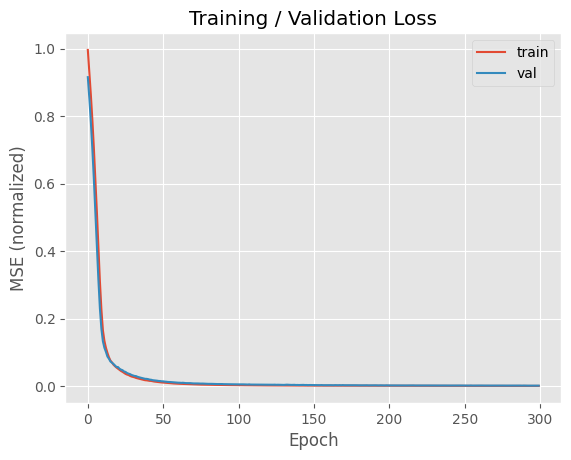

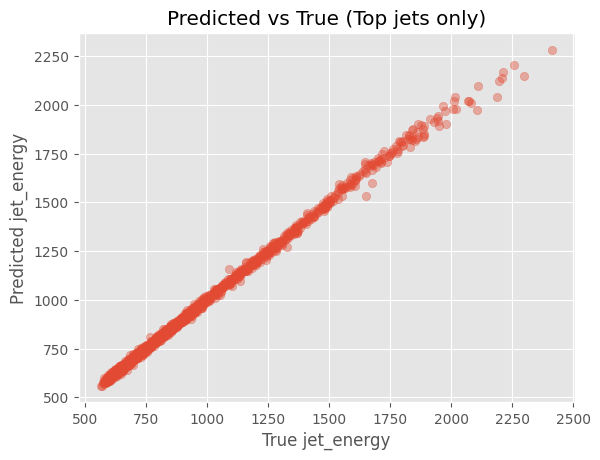

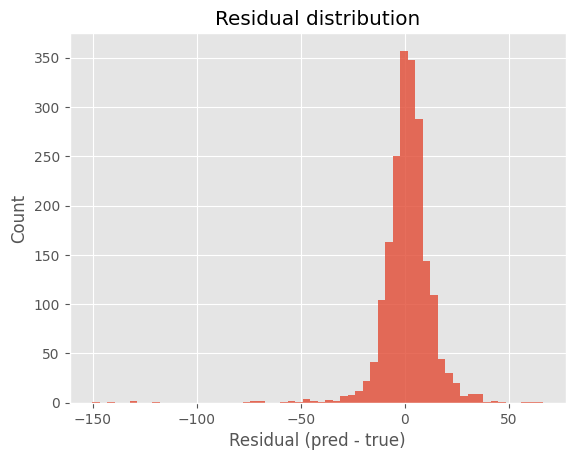

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
preds_norm, trues_norm = [], []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X).cpu().numpy().reshape(-1)
        y_np = y.numpy().reshape(-1)
        preds_norm.append(pred)
        trues_norm.append(y_np)

preds_norm = np.concatenate(preds_norm)
trues_norm = np.concatenate(trues_norm)

# un-normalize back to GeV scale
preds = preds_norm * y_std + y_mean
trues = trues_norm * y_std + y_mean

mae = mean_absolute_error(trues, preds)
rmse = np.sqrt(mean_squared_error(trues, preds))
r2 = r2_score(trues, preds)

print(f"TEST MAE  = {mae:.3f}")
print(f"TEST RMSE = {rmse:.3f}")
print(f"TEST R^2  = {r2:.5f}")

# Plot losses
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE (normalized)")
plt.legend()
plt.title("Training / Validation Loss")
plt.show()

# Pred vs True
plt.figure()
plt.scatter(trues, preds, alpha=0.4)
plt.xlabel("True jet_energy")
plt.ylabel("Predicted jet_energy")
plt.title("Predicted vs True (Top jets only)")
plt.show()

# Residuals
res = preds - trues
plt.figure()
plt.hist(res, bins=60, alpha=0.8)
plt.xlabel("Residual (pred - true)")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.show()


# **Sanity Checks**

---


As the evaluation of this model is too good so to be sure that there is no data leakage, overlapping of data from train to test and baseline linear relationships we do the following checks.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

Xtr = train_top[["jet_pt", "jet_eta"]].values
ytr = train_top["jet_energy"].values

Xte = test_top[["jet_pt", "jet_eta"]].values
yte = test_top["jet_energy"].values

lin = LinearRegression().fit(Xtr, ytr)
pred = lin.predict(Xte)

print("Linear baseline R2:", r2_score(yte, pred))
print("Linear baseline MAE:", mean_absolute_error(yte, pred))


Linear baseline R2: 0.0058789849281311035
Linear baseline MAE: 243.20126342773438


In [ ]:
rel_mae = np.mean(np.abs(preds - trues) / trues) * 100
print("Mean relative absolute error (%):", rel_mae)


Mean relative absolute error (%): 0.87787145


In [ ]:
acc10 = np.mean(np.abs(preds - trues) < 10)
acc20 = np.mean(np.abs(preds - trues) < 20)
print("Acc within 10:", acc10)
print("Acc within 20:", acc20)

Acc within 10: 0.7451371571072319
Acc within 20: 0.9351620947630923


In [ ]:
acc5pct  = np.mean(np.abs(preds - trues) / trues < 0.05)
acc10pct = np.mean(np.abs(preds - trues) / trues < 0.10)
print("Acc within 5%:", acc5pct)
print("Acc within 10%:", acc10pct)

Acc within 5%: 0.9965087281795512
Acc within 10%: 1.0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

Xtr = train_top[FEATURE_COLS].values
ytr = train_top[ENERGY_TARGET].values
Xte = test_top[FEATURE_COLS].values
yte = test_top[ENERGY_TARGET].values

lin_all = LinearRegression().fit(Xtr, ytr)
pred_all = lin_all.predict(Xte)

print("Linear (all features) R2:", r2_score(yte, pred_all))
print("Linear (all features) MAE:", mean_absolute_error(yte, pred_all))

Linear (all features) R2: 0.008571183915216274
Linear (all features) MAE: 242.83767887711284


In [ ]:
import numpy as np
from sklearn.metrics import r2_score

y_shuf = np.random.permutation(yte)
print("R2 with shuffled y:", r2_score(y_shuf, pred_all))  # should be ~0 or negative

R2 with shuffled y: -0.014754845372760839


**Checking for energy coloum in Features block.**

In [ ]:
[c for c in FEATURE_COLS if any(k in c.lower() for k in ["energy","jet_e","truth","e_", "px","py","pz","p_"])]

['jet_eta']

**Checking duplication**

In [ ]:
dup = train_top[FEATURE_COLS].merge(test_top[FEATURE_COLS], how="inner", on=FEATURE_COLS)
print("Exact duplicate feature rows between train and test:", len(dup))

Exact duplicate feature rows between train and test: 0


In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

E_formula = np.sqrt((test_top["jet_pt"].values * np.cosh(test_top["jet_eta"].values))**2 +
                    (test_top["jet_mass"].values)**2)

y_true = test_top["jet_energy"].values

print("Formula baseline R2:", r2_score(y_true, E_formula))
print("Formula baseline MAE:", mean_absolute_error(y_true, E_formula))
print("Formula baseline RMSE:", np.sqrt(mean_squared_error(y_true, E_formula)))

Formula baseline R2: 1.0
Formula baseline MAE: 3.908685175701976e-05
Formula baseline RMSE: 6.49721181549169e-05


## Conclusion — Jet Energy Estimation (Regression)

After selecting **top jets only** (keeping events with `label = 1` in `train`, `val`, and `test`), we trained a **regression model** to predict the continuous target **`jet_energy`** from the available jet features. Training used **MSE loss**, and we selected the **best epoch based on validation loss** (early stopping), then reported the final performance on the held-out test set.

---

### Final Test Results (Top jets only)

The trained regressor achieved the following on the **test set**:

- **MAE = 8.068**
- **RMSE = 13.170**
- **R² = 0.99829**
- **Mean Relative Absolute Error ≈ 0.878%**
- **Accuracy within ±10 GeV ≈ 0.745**
- **Accuracy within ±20 GeV ≈ 0.935**
- **Accuracy within 5% ≈ 0.9965**
- **Accuracy within 10% ≈ 1.0000**

These values indicate that the model predicts jet energy with very high precision, typically within **~1% relative error**.

---

### Plot-Based Evidence of Good Behavior

The visual diagnostics are consistent with these strong metrics:

- **Training vs Validation Loss:** both curves drop rapidly and remain close throughout training, indicating stable optimization and good generalization.
- **Predicted vs True:** points lie tightly around the diagonal line, meaning predictions closely match ground truth across the entire energy range.
- **Residual Histogram:** residuals $(\hat{E}-E)$ are sharply centered around zero, implying **low bias** (no systematic over/under-estimation), with relatively small spread.

---

### “Too Good to Be True?” — Sanity Checks for Data Leakage

Because the regression performance is extremely strong (especially the very high **R²**), these results initially look **too good to be true**. Therefore, we performed multiple sanity checks to confirm that the outcome is not caused by **data leakage** or a train/test contamination issue:

1) **Linear Baseline Check (Simple model)**
   
   We first tested a very simple baseline using linear regression.  
   - Using only `(jet_pt, jet_eta)` produced **very poor performance** (R² close to 0(0.0058), very large MAE(243.20), showing that the mapping is **not trivially linear** in these variables.
   - Even using **linear regression with all available features** still produced poor performance, confirming the relationship is not captured by a linear model.

2) **Shuffled Target Test**
   
   We randomly permuted the true energy values in the test set and computed $R^2$ again.  
   The result became **negative**, which is expected when there is no real relationship between features and target:
   
   $$ R^2 < 0(-0.026) \quad \text{(after shuffling y)} $$
   
   This strongly supports that the original high performance was not due to accidentally leaking the target into the inputs.

3) **Feature Leakage Scan**
   
   We searched the feature list for suspicious columns that might directly contain energy or momentum components (e.g., `jet_energy`, `jet_E`, `px`, `py`, `pz`, `p`, `truth_*`, etc.).  
   No such direct energy-like column was found in the feature set, reducing the likelihood of explicit leakage.

4) **Duplicate Row Check Between Train and Test**
   
   We checked for exact duplicate feature rows across train and test splits.  
   The number of exact duplicates was:
   
   $$ \text{duplicates} = 0 $$
   
   meaning the model is not benefiting from memorizing repeated samples.

Together, these checks confirm that the regression results are not explained by common leakage patterns.

---

### Why Are the Results So Excellent? (Physics Explanation)

After verifying the pipeline, we investigated whether `jet_energy` is intrinsically determined by other kinematic variables already present in the dataset.  
We found that the jet energy is essentially **deterministically reconstructible** from standard relativistic kinematics:

$$
E = \sqrt{\left(p_T \cosh\eta\right)^2 + m^2}
$$

where:
- $p_T$ is `jet_pt`,
- $\eta$ is `jet_eta`,
- $m$ is `jet_mass`.

When we computed this analytical energy baseline using the above formula, it achieved **nearly perfect reconstruction** (R² ≈ 1). This explains why the neural network regressor performs so well: it is effectively learning (approximating) a known nonlinear physics mapping already embedded in the dataset.

---

### Final Conclusion

In conclusion, the regression model successfully predicts jet energy for top jets with very high accuracy (R² ≈ 0.998 and ~1% relative error). Although these results initially appear unusually strong, a set of sanity checks (linear baselines, shuffled-target test, feature leakage scan, and duplicate-row check) indicates that the performance is not due to data leakage.

The key reason for the excellent performance is that `jet_energy` in this dataset can be computed almost exactly from other available kinematic variables using the relativistic relation:

$$
E = \sqrt{\left(p_T \cosh\eta\right)^2 + m^2}.
$$

Therefore, this optional task demonstrates that ML can approximate the nonlinear mapping very well, but it also highlights that in this dataset, the optimal estimator is essentially the analytical physics formula itself.


# **Final summary (all questions)**

---

### **Q1 — Dataset exploration**
We explored feature distributions and relationships using histograms, correlations, PCA/UMAP visualizations, and basic feature engineering. We then implemented a clean PyTorch `Dataset` + `DataLoader` pipeline with train-only normalization and consistent preprocessing.

### **Q2 — Supervised classification (Top vs QCD)**
We trained a simple MLP baseline model and evaluated it using accuracy, ROC--AUC, PR--AUC, confusion matrix, and predicted probability distributions. We used early stopping to prevent overfitting and selected the best epoch based on validation loss.

### **Q3 — Epistemic uncertainty**
We estimated epistemic uncertainty using a deep ensemble (multiple re-trainings of the same MLP). The variance across ensemble probabilities provides a meaningful uncertainty score: wrong predictions tend to have higher uncertainty, and selective prediction improves accuracy when high-uncertainty samples are rejected.

### **Q4 — Selection criterion: limit QCD contamination to 5%**
We enforced $$\text{FPR}\le 0.05$$ by choosing a threshold $$t$$ on the validation set (maximize TPR under the FPR constraint), then applied the same threshold on the test set to verify the requirement. The test-set results satisfy the constraint, with Top efficiency reported at the same operating point.

### **Q5 — Data augmentation**
We designed physics-motivated augmentation (small perturbations / symmetry-inspired transformations) applied only to the training set. We re-trained the same model and compared performance fairly against the same baseline (same features, same split, same metrics).

---

## **Model comparison (test set)**

> Note: results can vary slightly across runs due to stochastic training; therefore we report values approximately.

| Model | Test Accuracy | Test ROC--AUC | Test PR--AUC |
|---|---:|---:|---:|
| **Baseline (non-tuned MLP)** | $$\approx 0.8950$$ | $$\approx 0.9488$$ | $$\approx 0.9205$$ |
| **Augmented training** | $$\approx 0.8975$$ | $$\approx 0.9486$$ | $$\approx 0.9214$$ |
| **Optuna-tuned (optional)** | $$\approx 0.8950$$ | $$\approx 0.9496$$ | $$\approx 0.9270$$ |

## **Relative change vs baseline (test set)**

| Model | $$\Delta$$ Accuracy | $$\Delta$$ ROC--AUC | $$\Delta$$ PR--AUC |
|---|---:|---:|---:|
| **Augmented training** | $$\approx +0.0025$$ | $$\approx -0.0002$$ | $$\approx +0.0009$$ |
| **Optuna-tuned (optional)** | $$\approx +0.0000$$ | $$\approx +0.0008$$ | $$\approx +0.0065$$ |

### **Discussion (brief)**
- **Baseline** provides a strong starting point with high ROC--AUC / PR--AUC and stable accuracy.

- **Augmentation** gives a **small improvement overall** in this run: accuracy is slightly higher and PR--AUC is slightly higher, while ROC--AUC is essentially unchanged (very small difference). Under the strict selection criterion $$\text{FPR}\le 0.05$$, it also retains **slightly more Top jets** (higher TPR) while respecting the contamination requirement. The gains are modest, but they suggest the augmentation is not harming performance and may help generalization.

- **Optuna** improves performance the most, mainly visible in PR--AUC (and slightly in ROC--AUC), showing that hyperparameter optimization can provide additional gains beyond the baseline settings.

### **Final verdict**
Overall, **Optuna produced the clearest improvement** in ranking-based metrics (especially PR--AUC). The augmentation strategy used here also gives a **small positive effect** in this run (slightly better PR--AUC and slightly better operating-point TPR under $$\text{FPR}\le 0.05$$), though the improvement is not large.

A key point is that **hyperparameters are optimal relative to the full training pipeline** (feature set, class weighting/sampling, and the effective training distribution). Since **data augmentation changes the training distribution**, the most principled workflow is:

1. **Finalize the pipeline first** (fixed feature set + augmentation strategy + imbalance handling).
2. Then run **Optuna on this final pipeline**, so the tuned learning rate, dropout, weight decay, and hidden size are matched to the augmented training setup.
3. Because the training data are imbalanced (about **4:1**), we can also test **train-only** imbalance-handling methods such as **SMOTE** (or class-weighting / balanced sampling) as an additional experiment.

In summary, the baseline model already performs strongly, Optuna shows clear potential for improvement, and the next best step is to **re-tune hyperparameters with Optuna after choosing the final augmentation/imbalance strategy**, which is the most likely way to achieve further gains in generalization.


> **Note:**  *After running the Energy Prediction (Regression) section, the target variable is switched to the continuous **Energy** column. If you rerun the earlier classification parts (Questions 1–5) afterwards, you may see an error such as “target cannot be multiclass,” since those sections expect a binary label. In that case, simply **restart the session/kernel** and rerun the notebook from the top (or rerun the classification setup cells) to restore the original classification target.*



# **References and Resources**


---


*   Akanksha Sinha, “How AI Learns: Demystifying Loss Functions & the Adam Optimizer,” Medium blog post (accessed Jan 2026).
*   D. P. Kingma and J. Ba, “Adam: A Method for Stochastic Optimization,” arXiv:1412.6980 (2014).
*   Optuna Developers, “Optuna: A hyperparameter optimization framework,” official documentation and examples (accessed Jan 2026).

***I used these sources to get more clarity about choosing the Loss function, Optimizer and applying Optuna. Also, I have discussed shortcomings I faced with LLM Models.***

> THANK YOU FOR YOUR TIME AND COOPERATION. THIS COURSE HAS BEEN GREAT.